 Introduction to NLP -- Coursework

In this notebook, I build an end-to-end information retrieval and RAG system for the Natural Questions dataset. I start with a TF-IDF baseline, then improve the retrieval system using dense embeddings, hybrid retrieval, query expansion, and cross-encoder re-ranking. I then use the best retrieval setup inside a RAG pipeline and finish with error analysis and final test-set submission.

## Notebook structure

0. **Setup and helper functions**
1. **Loading the Natural Questions dataset**
2. **Q1 — TF-IDF baseline**
3. **Q2 — Dense retrieval**
4. **Q3 — Advanced retrieval improvements**
5. **Q4 — RAG pipeline**
6. **Q5 — Error analysis and final evaluation**
7. **Final summary table**
8. **Held-out test set submission**

The notebook should be run from top to bottom. I cache larger files such as passage embeddings, FAISS indexes, and query elaborations so that later runs are faster.

## 0. Setup and helper functions

In this section, I import the libraries needed for the notebook and include the helper functions provided for the coursework. These functions load the Natural Questions data, calculate retrieval and generation metrics, and create the similarity heatmap used later in the analysis.

In [1]:
#!pip install -q datasets scikit-learn sentence-transformers faiss-cpu transformers seaborn

In [2]:
#Loading all the libraries
import os
import re
import string
import time
import uuid
from collections import Counter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import T5Tokenizer, T5ForConditionalGeneration
from datasets import load_dataset

#Checking whtever notebook has GPU or CPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
if DEVICE == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
  GPU: Tesla T4


### 0.1 Helper functions (verbatim from the helper notebook)

In [3]:
def load_nq_data(split="train"):
    """Load and flatten the natural-questions-short dataset for a given split.
    Returns: examples (list of dict), corpus (list of str), qrels (dict qid -> gold passage idx).
    """
    dataset = load_dataset("cjlovering/natural-questions-short", split=split)

    examples = []
    corpus_set = {}
    corpus = []
    qrels = {}

    for row in dataset:
        question = row["questions"][0]["input_text"]
        context  = row["contexts"]
        answer   = row["answers"][0]["span_text"]
        qid      = str(row["id"])
        has_ctx  = row["has_correct_context"]

        if context not in corpus_set:
            corpus_set[context] = len(corpus)
            corpus.append(context)
        passage_idx = corpus_set[context]

        examples.append({
            "id": qid, "question": question, "context": context,
            "answer": answer, "has_correct_context": has_ctx,
        })
        if has_ctx:
            qrels[qid] = passage_idx

    print(f"Loaded {len(examples)} examples | "
          f"{len(corpus)} unique passages | "
          f"{len(qrels)} questions with valid gold passage")
    return examples, corpus, qrels


def recall_at_k(results, qrels, k):
    if not qrels:
        raise ValueError("qrels is empty.")
    hits, evaluated = 0, 0
    for qid, gold_idx in qrels.items():
        if qid in results and gold_idx in results[qid][:k]:
            hits += 1
        evaluated += 1
    return hits / evaluated if evaluated > 0 else 0.0


def mean_reciprocal_rank(results, qrels):
    if not qrels:
        raise ValueError("qrels is empty.")
    rrs = []
    for qid, gold_idx in qrels.items():
        rr = 0.0
        if qid in results and gold_idx in results[qid]:
            rank = results[qid].index(gold_idx) + 1
            rr = 1.0 / rank
        rrs.append(rr)
    return float(np.mean(rrs))


def compute_retrieval_metrics(results, qrels, k_values=(1, 5, 20, 100)):
    metrics = {}
    print(f"Evaluated on {len(qrels)} queries\n")
    print(f"{'Metric':<15} {'Score':>8}")
    print("-" * 25)
    for k in k_values:
        r = recall_at_k(results, qrels, k)
        metrics[f"Recall@{k}"] = r
        print(f"{'Recall@'+str(k):<15} {r:>8.4f}")
    mrr = mean_reciprocal_rank(results, qrels)
    metrics["MRR"] = mrr
    print(f"{'MRR':<15} {mrr:>8.4f}")
    return metrics


In [4]:
def normalize_text(s: str) -> str:
    """SQuAD-style normalisation."""
    def remove_articles(t): return re.sub(r"\b(a|an|the)\b", " ", t)
    def white_space_fix(t): return " ".join(t.split())
    def remove_punc(t):
        exclude = set(string.punctuation)
        return "".join(ch for ch in t if ch not in exclude)
    return white_space_fix(remove_articles(remove_punc(s.lower())))


def exact_match_score(prediction, ground_truth):
    return int(normalize_text(prediction) == normalize_text(ground_truth))


def token_f1_score(prediction, ground_truth):
    pred_tokens = normalize_text(prediction).split()
    gold_tokens = normalize_text(ground_truth).split()
    if not pred_tokens or not gold_tokens:
        return float(pred_tokens == gold_tokens)
    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    p = num_same / len(pred_tokens)
    r = num_same / len(gold_tokens)
    return 2 * p * r / (p + r)


def compute_generation_metrics(predictions, gold_answers):
    """Returns dict with 'ExactMatch' and 'TokenF1' averaged across queries."""
    ems = [exact_match_score(predictions.get(q, ""), g) for q, g in gold_answers.items()]
    f1s = [token_f1_score(predictions.get(q, ""), g) for q, g in gold_answers.items()]
    em = float(np.mean(ems)) if ems else 0.0
    f1 = float(np.mean(f1s)) if f1s else 0.0
    print(f"Evaluated on {len(gold_answers)} queries")
    print(f"  Exact Match: {em:.4f}")
    print(f"  Token F1:    {f1:.4f}")
    return {"ExactMatch": em, "TokenF1": f1}


In [5]:
def plot_retrieval_similarity_heatmap(embeddings, labels,
                                      title="Passage Embedding Similarity",
                                      figsize=None, annot_fontsize=8):
    """Plot pairwise cosine similarity heatmap. Returns the figure."""
    n = len(labels)
    assert embeddings.shape[0] == n, (
        f"embeddings has {embeddings.shape[0]} rows but {n} labels given."
    )
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    normalised = embeddings / norms
    sim_matrix = np.clip(normalised @ normalised.T, -1.0, 1.0)

    if figsize is None:
        cell_size = max(0.6, 8.0 / n)
        figsize = (n * cell_size + 2, n * cell_size + 1.5)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        sim_matrix, ax=ax, vmin=-1.0, vmax=1.0, center=0.0, cmap="RdYlGn",
        annot=True, fmt=".2f", annot_kws={"size": annot_fontsize},
        linewidths=0.4, linecolor="lightgrey", square=True,
        xticklabels=labels, yticklabels=labels,
        cbar_kws={"label": "Cosine similarity", "shrink": 0.8},
    )
    ax.set_title(title, fontsize=13, pad=14)
    ax.set_xlabel("Passage", fontsize=10)
    ax.set_ylabel("Passage", fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()
    return fig


def make_short_label(text, max_words=6):
    words = text.split()
    if len(words) <= max_words:
        return text
    return " ".join(words[:max_words]) + "..."


## 1. Load Natural Questions dataset

Per the brief: *"The corpus is the set of all unique context passages in a given split."* For development we therefore use the **validation corpus** (`val_corpus`) and evaluate against `val_qrels`. The train split is loaded too — useful for an optional sanity check in Q1 and for any later development work.

In [6]:
# Load the validation split for development/testing.
print("Loading validation split...")
val_examples, val_corpus, val_qrels = load_nq_data(split="validation")

# Load the training split for model development.
print("\nLoading training split (for optional comparison/model development)...")
train_examples, train_corpus, train_qrels = load_nq_data(split="train")

# Keep only validation examples with a known gold passage.
eval_examples = [ex for ex in val_examples if ex["id"] in val_qrels]

# Store the main fields used later in the notebook.
queries = [ex["question"] for ex in eval_examples]
qids = [ex["id"] for ex in eval_examples]
gold_answers = {ex["id"]: ex["answer"] for ex in eval_examples}

print(f"\nUsing {len(eval_examples)} validation queries with valid gold passages.")


Loading validation split...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

train.json:   0%|          | 0.00/14.1M [00:00<?, ?B/s]

dev.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/13933 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/871 [00:00<?, ? examples/s]

Loaded 871 examples | 832 unique passages | 871 questions with valid gold passage

Loading training split (for optional comparison/model development)...
Loaded 13933 examples | 10866 unique passages | 13933 questions with valid gold passage

Using 871 validation queries with valid gold passages.


## 2. Q1 — TF-IDF Sparse Retrieval Baseline

In this section, I build a sparse TF-IDF retrieval baseline. This gives me a simple starting point that the later dense and hybrid systems can be compared against.

For the TF-IDF vectorizer, I lowercase the text, remove English stop words, and use unigrams and bigrams. I also set `min_df=2` and `max_df=0.95` to remove terms that are either too rare or too common to be useful. I use L2 normalisation so that the dot product between vectors works like cosine similarity.

I do not use stemming or lemmatisation because many answers in this dataset involve names, places, dates, and titles, where changing word forms could sometimes remove useful information.

In [7]:
# Create the TF-IDF vectorizer with the preprocessing choices explained above.
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    norm="l2",
)

# Build the TF-IDF matrix for the validation corpus.
t0 = time.time()
doc_matrix = vectorizer.fit_transform(val_corpus)
build_time_tfidf = time.time() - t0

print(f"TF-IDF index built in {build_time_tfidf:.2f}s")
print(f"  Shape: {doc_matrix.shape}  Non-zeros: {doc_matrix.nnz:,}")


TF-IDF index built in 0.15s
  Shape: (832, 9310)  Non-zeros: 47,252


### 2.2 `retrieve(query, k)` and dev-set evaluation

In [8]:
def retrieve(query: str, k: int = 100):
    """Return the top-k passage indices using TF-IDF cosine similarity."""
    q_vec = vectorizer.transform([query])
    sims = linear_kernel(q_vec, doc_matrix).ravel()

    if k >= len(sims):
        top_idx = np.argsort(-sims)
    else:
        part = np.argpartition(-sims, k)[:k]
        top_idx = part[np.argsort(-sims[part])]

    return top_idx.tolist()


# Evaluate TF-IDF retrieval for all validation queries.
K = 100
t0 = time.time()

q_matrix = vectorizer.transform(queries)
sims_all = linear_kernel(q_matrix, doc_matrix)

results = {}

for row_i, qid in enumerate(qids):
    s = sims_all[row_i]
    part = np.argpartition(-s, K)[:K]
    top_idx = part[np.argsort(-s[part])]
    results[qid] = top_idx.tolist()

print(f"TF-IDF retrieval for {len(qids)} queries: {time.time() - t0:.2f}s")

print()
tfidf_metrics = compute_retrieval_metrics(results, val_qrels)


TF-IDF retrieval for 871 queries: 0.03s

Evaluated on 871 queries

Metric             Score
-------------------------
Recall@1          0.5476
Recall@5          0.7842
Recall@20         0.8794
Recall@100        0.9173
MRR               0.6546


In [9]:
# Put the TF-IDF retrieval scores into a small results table.
q1_table = pd.DataFrame([{
    "System":     "TF-IDF (sparse baseline)",
    "Recall@1":   tfidf_metrics["Recall@1"],
    "Recall@5":   tfidf_metrics["Recall@5"],
    "Recall@20":  tfidf_metrics["Recall@20"],
    "Recall@100": tfidf_metrics["Recall@100"],
    "MRR":        tfidf_metrics["MRR"],
}]).set_index("System")

print("Q1 — TF-IDF baseline on the development set")
print("=" * 60)
print(q1_table.round(4).to_string())


Q1 — TF-IDF baseline on the development set
                          Recall@1  Recall@5  Recall@20  Recall@100     MRR
System                                                                     
TF-IDF (sparse baseline)    0.5476    0.7842     0.8794      0.9173  0.6546


In [10]:
# Find TF-IDF cases where the gold passage is not in the top 20.
tfidf_failures_top20 = []

for ex in eval_examples:
    qid = ex["id"]
    gold_idx = val_qrels[qid]
    ranked = results[qid]

    if gold_idx not in ranked[:20]:
        tfidf_failures_top20.append({
            "qid": qid,
            "question": ex["question"],
            "gold_answer": ex["answer"],
            "gold_passage": val_corpus[gold_idx],
            "top1_passage": val_corpus[ranked[0]],
            "top1_idx": ranked[0]
        })

print(f"Number of TF-IDF failures where gold passage is not in top 20: {len(tfidf_failures_top20)}")

for i, case in enumerate(tfidf_failures_top20[:5], start=1):
    print("\n" + "=" * 80)
    print(f"Failure {i}: {case['qid']}")
    print("Question:", case["question"])
    print("Gold answer:", case["gold_answer"])
    print("\nTop-1 retrieved passage:")
    print(case["top1_passage"][:500])
    print("\nGold passage:")
    print(case["gold_passage"][:500])

Number of TF-IDF failures where gold passage is not in top 20: 105

Failure 1: 5770553296217961046
Question: what is the shannara chronicles season 2 based on
Gold answer: The Sword of Shannara Trilogy

Top-1 retrieved passage:
My Name Is Earl ( season 4 ) DVD cover Country of origin United States No. of episodes 27 Release Original network NBC Original release September 25 , 2008 -- May 14 , 2009 Season chronology ← Previous Season 3 List of My Name Is Earl episodes

Gold passage:
The Shannara Chronicles Genre Fantasy Created by Alfred Gough Miles Millar Based on The Sword of Shannara Trilogy by Terry Brooks Starring Austin Butler Poppy Drayton Ivana Baquero Manu Bennett Aaron Jakubenko Marcus Vanco Malese Jow Vanessa Morgan Gentry White Opening theme `` Until We Go Down '' by Ruelle Composer ( s ) Felix Erskine Lukas Burton Country of origin United States Original language ( s ) English No. of seasons No. of episodes 20 ( list of episodes ) Production Executive producer 

Failure 2: 

## 3. Q2 — Dense Retrieval

In this section, I replace the TF-IDF baseline with dense retrieval using sentence embeddings. The main reason for doing this is that dense vectors can capture meaning, not just exact word overlap, so they should handle paraphrasing and vocabulary mismatch better than TF-IDF.

### 3.1 Bi-encoder choice

For my main dense retriever, I use `sentence-transformers/all-MiniLM-L6-v2`. I chose this model because it is small, fast, and suitable for running in Colab. It produces 384-dimensional embeddings, which keeps the index smaller and makes similarity search quicker. I also normalise the embeddings so that dot product similarity works like cosine similarity.

Later in this section, I compare it with `sentence-transformers/all-mpnet-base-v2`, which is a larger model. This lets me check whether the stronger model gives better retrieval performance and whether the improvement is worth the extra encoding time.

In [11]:
# Set the main dense retrieval model.
PRIMARY_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

# Load the sentence-transformer model on the available device.
print(f"Loading {PRIMARY_MODEL_NAME}...")
t0 = time.time()
encoder = SentenceTransformer(PRIMARY_MODEL_NAME, device=DEVICE)
print(f"  Loaded in {time.time()-t0:.1f}s | dim={encoder.get_sentence_embedding_dimension()}")


Loading sentence-transformers/all-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Loaded in 8.5s | dim=384


/tmp/ipykernel_959/2556369411.py:8: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"  Loaded in {time.time()-t0:.1f}s | dim={encoder.get_sentence_embedding_dimension()}")


### 3.2 Encode the validation corpus (cached to disk)

In [12]:
def model_cache_path(model_name: str, tag: str = "val") -> str:
    """Create a safe cache filename for a model."""
    safe = model_name.replace("/", "__")
    return f"passage_embeddings_{safe}_{tag}.npy"


def encode_corpus(
    model: SentenceTransformer,
    corpus: list,
    cache_path: str,
    batch_size: int = 16
) -> np.ndarray:
    """Encode passages and save/load the embeddings from disk."""

    # Reuse saved embeddings if they already exist.
    if os.path.exists(cache_path):
        print(f"  Loading cached embeddings from {cache_path} ...")
        emb = np.load(cache_path)
        print(f"  Shape: {emb.shape}")
        return emb

    # Encode the corpus in batches and normalise the vectors.
    print(f"  Encoding {len(corpus):,} passages (batch_size={batch_size}) ...")
    t0 = time.time()

    emb = model.encode(
        corpus,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype(np.float32)

    elapsed = time.time() - t0
    print(f"  Encoded in {elapsed:.1f}s ({len(corpus) / elapsed:.0f} passages/sec)")

    np.save(cache_path, emb)
    return emb


# Encode the validation corpus using the primary dense model.
primary_cache = model_cache_path(PRIMARY_MODEL_NAME, tag="val")

t_enc_start = time.time()
passage_embeddings = encode_corpus(
    encoder,
    val_corpus,
    primary_cache,
    batch_size=16
)

encode_time_primary = time.time() - t_enc_start

print(
    f"\nPassage matrix: {passage_embeddings.shape} "
    f"({passage_embeddings.nbytes / 1e6:.1f} MB)"
)


  Encoding 832 passages (batch_size=16) ...


Batches:   0%|          | 0/52 [00:00<?, ?it/s]

  Encoded in 2.5s (336 passages/sec)

Passage matrix: (832, 384) (1.3 MB)


### 3.3 Dense retrieval function

In this step, I use the dense passage embeddings to retrieve the most similar passages for each question. Since the query and passage embeddings are normalised, I can use a dot product as the similarity score. For the validation corpus, brute-force search with NumPy is fast enough, so I use FAISS later in the RAG section where a vector database is required.

In [13]:
def retrieve_dense(query: str, k: int = 100, model=None, passage_emb=None):
    """Return the top-k passage indices using dense similarity."""

    if model is None:
        model = encoder
    if passage_emb is None:
        passage_emb = passage_embeddings

    # Encode the query using the same embedding model.
    q_vec = model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype(np.float32)[0]

    # Rank passages by dot product similarity.
    sims = passage_emb @ q_vec

    if k >= len(sims):
        return np.argsort(-sims).tolist()

    part = np.argpartition(-sims, k)[:k]
    return part[np.argsort(-sims[part])].tolist()


# Evaluate dense retrieval on all validation queries.
t0 = time.time()

query_embeddings = encoder.encode(
    queries,
    batch_size=64,
    show_progress_bar=False,
    convert_to_numpy=True,
    normalize_embeddings=True
).astype(np.float32)

sims_all_dense = query_embeddings @ passage_embeddings.T

dense_results = {}

for row_i, qid in enumerate(qids):
    s = sims_all_dense[row_i]
    part = np.argpartition(-s, K)[:K]
    top_idx = part[np.argsort(-s[part])]
    dense_results[qid] = top_idx.tolist()

print(f"Dense retrieval for {len(qids)} queries: {time.time() - t0:.2f}s")

print(f"\nDense ({PRIMARY_MODEL_NAME})")
print("-" * 60)

dense_metrics = compute_retrieval_metrics(dense_results, val_qrels)


Dense retrieval for 871 queries: 0.30s

Dense (sentence-transformers/all-MiniLM-L6-v2)
------------------------------------------------------------
Evaluated on 871 queries

Metric             Score
-------------------------
Recall@1          0.9208
Recall@5          0.9943
Recall@20         0.9977
Recall@100        1.0000
MRR               0.9537


### 3.4 Side-by-side comparison: TF-IDF vs Dense

In [14]:
# Compare the sparse baseline with the dense retriever.
comparison_q2 = pd.DataFrame([
    {"System": "TF-IDF (Q1)",
     "Recall@1":   tfidf_metrics["Recall@1"],
     "Recall@5":   tfidf_metrics["Recall@5"],
     "Recall@20":  tfidf_metrics["Recall@20"],
     "Recall@100": tfidf_metrics["Recall@100"],
     "MRR":        tfidf_metrics["MRR"]},
    {"System": f"Dense ({PRIMARY_MODEL_NAME.split('/')[-1]})",
     "Recall@1":   dense_metrics["Recall@1"],
     "Recall@5":   dense_metrics["Recall@5"],
     "Recall@20":  dense_metrics["Recall@20"],
     "Recall@100": dense_metrics["Recall@100"],
     "MRR":        dense_metrics["MRR"]},
]).set_index("System")

# Add the improvement from TF-IDF to dense retrieval.
delta = comparison_q2.iloc[1] - comparison_q2.iloc[0]
delta.name = "Δ (Dense - TFIDF)"
comparison_q2 = pd.concat([comparison_q2, delta.to_frame().T])

print("Q1 vs Q2 — Development Set")
print("=" * 75)
print(comparison_q2.round(4).to_string())


Q1 vs Q2 — Development Set
                          Recall@1  Recall@5  Recall@20  Recall@100     MRR
TF-IDF (Q1)                 0.5476    0.7842     0.8794      0.9173  0.6546
Dense (all-MiniLM-L6-v2)    0.9208    0.9943     0.9977      1.0000  0.9537
Δ (Dense - TFIDF)           0.3731    0.2101     0.1183      0.0827  0.2991


**Brief note.** Dense retrieval improves the TF-IDF baseline because it can match passages by meaning rather than only exact word overlap. However, TF-IDF can still be useful for queries with rare exact terms, so I test hybrid retrieval in Q3.

### 3.5 Two-model comparison

For the model comparison, I test two bi-encoders of different sizes: `all-MiniLM-L6-v2` and `all-mpnet-base-v2`. The aim is to compare retrieval quality with encoding cost, using Recall@20 and the approximate time taken to encode the validation corpus.

In [17]:
def evaluate_model(model_name, val_corpus, queries, qids, val_qrels,
                   batch_size=16, k=100):
    """Evaluate one dense bi-encoder on the validation set."""

    print(f"\n=== {model_name} ===")
    m = SentenceTransformer(model_name, device=DEVICE)

    # Encode or load the passage embeddings.
    cache = model_cache_path(model_name, tag="val")
    cached_before = os.path.exists(cache)

    t0 = time.time()
    p_emb = encode_corpus(m, val_corpus, cache, batch_size=batch_size)
    corpus_enc_time = time.time() - t0

    if cached_before:
        print("  (using cache; reported encode time is load-from-disk)")

    # Encode all validation questions.
    q_emb = m.encode(
        queries,
        batch_size=64,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False
    ).astype(np.float32)

    # Rank passages for each question.
    sims = q_emb @ p_emb.T
    res = {}

    for i, qid in enumerate(qids):
        s = sims[i]
        part = np.argpartition(-s, k)[:k]
        res[qid] = part[np.argsort(-s[part])].tolist()

    metrics = compute_retrieval_metrics(res, val_qrels)

    return {
        "model":         model_name,
        "embedding_dim": m.get_sentence_embedding_dimension(),
        "encode_time_s": corpus_enc_time,
        "Recall@1":      metrics["Recall@1"],
        "Recall@5":      metrics["Recall@5"],
        "Recall@20":     metrics["Recall@20"],
        "Recall@100":    metrics["Recall@100"],
        "MRR":           metrics["MRR"],
    }


# Compare the primary model with a larger bi-encoder.
SECONDARY_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

result_primary = evaluate_model(
    PRIMARY_MODEL_NAME,
    val_corpus,
    queries,
    qids,
    val_qrels
)

result_secondary = evaluate_model(
    SECONDARY_MODEL_NAME,
    val_corpus,
    queries,
    qids,
    val_qrels
)

# Put the comparison into a table.
model_table = pd.DataFrame([result_primary, result_secondary])
model_table["model"] = model_table["model"].str.split("/").str[-1]

model_table = model_table[
    [
        "model",
        "embedding_dim",
        "Recall@20",
        "encode_time_s",
        "Recall@1",
        "Recall@5",
        "Recall@100",
        "MRR"
    ]
]

print("\nBi-encoder comparison (development set)")
print("=" * 95)
print(model_table.round(4).to_string(index=False))


=== sentence-transformers/all-MiniLM-L6-v2 ===


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Loading cached embeddings from passage_embeddings_sentence-transformers__all-MiniLM-L6-v2_val.npy ...
  Shape: (832, 384)
  (using cache; reported encode time is load-from-disk)
Evaluated on 871 queries

Metric             Score
-------------------------
Recall@1          0.9208
Recall@5          0.9943
Recall@20         0.9977
Recall@100        1.0000
MRR               0.9537

=== sentence-transformers/all-mpnet-base-v2 ===


/tmp/ipykernel_959/1947459489.py:41: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  "embedding_dim": m.get_sentence_embedding_dimension(),


...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Encoding 832 passages (batch_size=16) ...


Batches:   0%|          | 0/52 [00:00<?, ?it/s]

  Encoded in 10.8s (77 passages/sec)
Evaluated on 871 queries

Metric             Score
-------------------------
Recall@1          0.9506
Recall@5          0.9966
Recall@20         1.0000
Recall@100        1.0000
MRR               0.9716

Bi-encoder comparison (development set)
            model  embedding_dim  Recall@20  encode_time_s  Recall@1  Recall@5  Recall@100    MRR
 all-MiniLM-L6-v2            384     0.9977         0.0013    0.9208    0.9943         1.0 0.9537
all-mpnet-base-v2            768     1.0000        10.7959    0.9506    0.9966         1.0 0.9716


/tmp/ipykernel_959/1947459489.py:41: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  "embedding_dim": m.get_sentence_embedding_dimension(),


## 4. Q3 — Advanced Retrieval Improvements

In this section, I try to improve the dense retrieval system from Q2. I test four retrieval changes and tune one main parameter for each method on the development set.

The four methods are:

1. **Reciprocal Rank Fusion**, where I combine TF-IDF and dense rankings.
2. **Weighted score fusion**, where I combine sparse and dense scores using different values of `alpha`.
3. **Cross-encoder re-ranking**, where I re-rank the top candidates from the retriever.
4. **LLM-based query expansion**, where I expand the question and combine it with the original query.

The aim is to see which method gives the best improvement over the Q2 dense baseline, rather than assuming every added technique will help.

### 4.1 Hybrid retrieval — Reciprocal Rank Fusion

In this method, I combine the TF-IDF ranking and the dense ranking using Reciprocal Rank Fusion. Instead of combining the raw similarity scores, RRF uses the rank position of each passage. This is useful because TF-IDF scores and dense similarity scores are on different scales.

I tune the `k_rrf` value on the development set to see which setting gives the best retrieval performance.

In [18]:
def rrf_fuse(rankings_list, k_rrf=60, top_k=100):
    """Combine multiple rankings using Reciprocal Rank Fusion."""

    # Collect all query IDs from the ranking dictionaries.
    qids_set = set()
    for r in rankings_list:
        qids_set.update(r.keys())

    fused = {}

    for qid in qids_set:
        scores = {}

        # Add an RRF score for each document based on its rank position.
        for ranker in rankings_list:
            for rank_pos, doc in enumerate(ranker.get(qid, []), start=1):
                scores[doc] = scores.get(doc, 0.0) + 1.0 / (k_rrf + rank_pos)

        fused[qid] = sorted(scores, key=scores.get, reverse=True)[:top_k]

    return fused


print("Sweeping k_rrf for Reciprocal Rank Fusion")
print("=" * 75)

rrf_rows = []

# Try different k_rrf values and compare retrieval performance.
for k_rrf in [10, 30, 60, 100]:
    fused = rrf_fuse([results, dense_results], k_rrf=k_rrf, top_k=100)

    row = {
        "k_rrf":      k_rrf,
        "Recall@1":   recall_at_k(fused, val_qrels, 1),
        "Recall@5":   recall_at_k(fused, val_qrels, 5),
        "Recall@20":  recall_at_k(fused, val_qrels, 20),
        "Recall@100": recall_at_k(fused, val_qrels, 100),
        "MRR":        mean_reciprocal_rank(fused, val_qrels)
    }

    rrf_rows.append(row)

    print(
        f"  k_rrf={k_rrf:>3} | "
        f"R@1={row['Recall@1']:.4f}  "
        f"R@20={row['Recall@20']:.4f}  "
        f"MRR={row['MRR']:.4f}"
    )

# Select the best RRF setting by MRR.
rrf_table = pd.DataFrame(rrf_rows).set_index("k_rrf")
best_k_rrf = int(rrf_table["MRR"].idxmax())

print(f"\nBest k_rrf by MRR: {best_k_rrf}")

best_rrf_results = rrf_fuse(
    [results, dense_results],
    k_rrf=best_k_rrf,
    top_k=100
)

rrf_metrics = {k: rrf_table.loc[best_k_rrf, k] for k in rrf_table.columns}

Sweeping k_rrf for Reciprocal Rank Fusion
  k_rrf= 10 | R@1=0.7371  R@20=0.9977  MRR=0.8361
  k_rrf= 30 | R@1=0.7268  R@20=0.9954  MRR=0.8152
  k_rrf= 60 | R@1=0.7256  R@20=0.9874  MRR=0.8090
  k_rrf=100 | R@1=0.7256  R@20=0.9805  MRR=0.8077

Best k_rrf by MRR: 10


### 4.2 Hybrid retrieval — Weighted score fusion

In this method, I combine the TF-IDF and dense similarity scores directly. Since the two scores are on different scales, I normalise them first and then combine them using an `alpha` value.

A higher `alpha` gives more weight to dense retrieval, while a lower `alpha` gives more weight to TF-IDF. I test different `alpha` values on the development set to find the best balance.

In [19]:
def minmax_normalise(scores):
    """Normalise each query's scores between 0 and 1."""
    mn = scores.min(axis=1, keepdims=True)
    mx = scores.max(axis=1, keepdims=True)
    rng = np.where(mx > mn, mx - mn, 1.0)
    return (scores - mn) / rng


# Normalise TF-IDF and dense scores so they can be combined fairly.
sims_tfidf_dense = sims_all.toarray() if hasattr(sims_all, "toarray") else np.asarray(sims_all)

tfidf_norm = minmax_normalise(sims_tfidf_dense)
dense_norm = minmax_normalise(sims_all_dense)

print("Sweeping alpha for weighted score fusion")
print("=" * 75)

alpha_rows = []

# Try different weights between TF-IDF and dense retrieval.
for alpha in [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]:
    fused_scores = alpha * dense_norm + (1 - alpha) * tfidf_norm
    fused_res = {}

    for row_i, qid in enumerate(qids):
        s = fused_scores[row_i]
        part = np.argpartition(-s, 100)[:100]
        fused_res[qid] = part[np.argsort(-s[part])].tolist()

    row = {
        "alpha":      alpha,
        "Recall@1":   recall_at_k(fused_res, val_qrels, 1),
        "Recall@5":   recall_at_k(fused_res, val_qrels, 5),
        "Recall@20":  recall_at_k(fused_res, val_qrels, 20),
        "Recall@100": recall_at_k(fused_res, val_qrels, 100),
        "MRR":        mean_reciprocal_rank(fused_res, val_qrels)
    }

    alpha_rows.append(row)

    print(
        f"  alpha={alpha:.1f} | "
        f"R@1={row['Recall@1']:.4f}  "
        f"R@20={row['Recall@20']:.4f}  "
        f"MRR={row['MRR']:.4f}"
    )

# Pick the best alpha based on MRR.
alpha_table = pd.DataFrame(alpha_rows).set_index("alpha")
best_alpha = float(alpha_table["MRR"].idxmax())

print(f"\nBest alpha by MRR: {best_alpha}")

# Build the final weighted-fusion ranking using the best alpha.
best_fused_scores = best_alpha * dense_norm + (1 - best_alpha) * tfidf_norm

best_weighted_results = {}

for row_i, qid in enumerate(qids):
    s = best_fused_scores[row_i]
    part = np.argpartition(-s, 100)[:100]
    best_weighted_results[qid] = part[np.argsort(-s[part])].tolist()

weighted_metrics = {k: alpha_table.loc[best_alpha, k] for k in alpha_table.columns}

Sweeping alpha for weighted score fusion
  alpha=0.0 | R@1=0.5476  R@20=0.8794  MRR=0.6546
  alpha=0.1 | R@1=0.5729  R@20=0.9449  MRR=0.6880
  alpha=0.3 | R@1=0.6625  R@20=0.9724  MRR=0.7601
  alpha=0.5 | R@1=0.7543  R@20=0.9966  MRR=0.8394
  alpha=0.7 | R@1=0.8898  R@20=0.9977  MRR=0.9353
  alpha=0.9 | R@1=0.9196  R@20=0.9977  MRR=0.9545
  alpha=1.0 | R@1=0.9208  R@20=0.9977  MRR=0.9537

Best alpha by MRR: 0.9


### 4.3 Pick the hybrid winner

In [20]:
# Choose the stronger hybrid method based on MRR
if rrf_metrics["MRR"] >= weighted_metrics["MRR"]:
    hybrid_results = best_rrf_results
    hybrid_metrics = rrf_metrics
    hybrid_label   = f"Hybrid-RRF (k_rrf={best_k_rrf})"
else:
    hybrid_results = best_weighted_results
    hybrid_metrics = weighted_metrics
    hybrid_label   = f"Hybrid-Weighted (alpha={best_alpha})"

print(f"Hybrid winner: {hybrid_label}")
print(f"  R@1={hybrid_metrics['Recall@1']:.4f}  R@20={hybrid_metrics['Recall@20']:.4f}  "
      f"MRR={hybrid_metrics['MRR']:.4f}")


Hybrid winner: Hybrid-Weighted (alpha=0.9)
  R@1=0.9196  R@20=0.9977  MRR=0.9545


### 4.4 Cross-encoder re-ranking

In this step, I use a cross-encoder to re-rank the best candidates from the hybrid retriever. Unlike the dense bi-encoder, the cross-encoder reads the question and passage together, so it can make a more accurate relevance judgement.

Because this is slower, I only apply it to the top `N` retrieved passages instead of the full corpus. I then test different values of `N` to find the best balance between accuracy and speed.

In [21]:
# Load the cross-encoder used for re-ranking.
print("Loading cross-encoder/ms-marco-MiniLM-L-6-v2 ...")
t0 = time.time()
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", device=DEVICE)
print(f"  Loaded in {time.time() - t0:.1f}s")


def cross_encoder_rerank(base_results, queries_list, qids_list, corpus,
                         cross_model, top_n=20, batch_size=32):
    """Re-rank the top-N retrieved passages for each query."""

    all_pairs = []
    pair_index = []

    # Build query-passage pairs for the cross-encoder.
    for qi, qid in enumerate(qids_list):
        for doc in base_results.get(qid, [])[:top_n]:
            all_pairs.append((queries_list[qi], corpus[doc]))
            pair_index.append((qi, doc))

    if not all_pairs:
        return dict(base_results)

    # Score each query-passage pair.
    scores = cross_model.predict(
        all_pairs,
        batch_size=batch_size,
        show_progress_bar=False
    )

    by_qid = {qid: [] for qid in qids_list}

    for (qi, doc), s in zip(pair_index, scores):
        by_qid[qids_list[qi]].append((doc, float(s)))

    reranked = {}

    # Re-rank the top-N and then append the remaining original results.
    for qid in qids_list:
        sorted_top = [d for d, _ in sorted(by_qid[qid], key=lambda x: -x[1])]
        tail = [d for d in base_results.get(qid, []) if d not in sorted_top]
        reranked[qid] = sorted_top + tail

    return reranked


print("\nSweeping top-N for cross-encoder re-ranking (on best hybrid)")
print("=" * 75)

ce_rows = []

# Test different numbers of candidates for re-ranking.
for top_n in [10, 20, 50, 100]:
    t0 = time.time()

    rer = cross_encoder_rerank(
        hybrid_results,
        queries,
        qids,
        val_corpus,
        cross_encoder,
        top_n=top_n,
        batch_size=64
    )

    elapsed = time.time() - t0

    row = {
        "top_n":      top_n,
        "Recall@1":   recall_at_k(rer, val_qrels, 1),
        "Recall@5":   recall_at_k(rer, val_qrels, 5),
        "Recall@20":  recall_at_k(rer, val_qrels, 20),
        "Recall@100": recall_at_k(rer, val_qrels, 100),
        "MRR":        mean_reciprocal_rank(rer, val_qrels),
        "time_s":     elapsed
    }

    ce_rows.append(row)

    print(
        f"  N={top_n:>3} | "
        f"R@1={row['Recall@1']:.4f}  "
        f"R@20={row['Recall@20']:.4f}  "
        f"MRR={row['MRR']:.4f}  | "
        f"{elapsed:5.1f}s"
    )

# Select the best re-ranking depth using MRR.
ce_table = pd.DataFrame(ce_rows).set_index("top_n")
best_top_n = int(ce_table["MRR"].idxmax())

print(f"\nBest top_N by MRR: {best_top_n}")

reranked_results = cross_encoder_rerank(
    hybrid_results,
    queries,
    qids,
    val_corpus,
    cross_encoder,
    top_n=best_top_n,
    batch_size=64
)

reranked_metrics = {
    k: ce_table.loc[best_top_n, k]
    for k in ce_table.columns
    if k != "time_s"
}

Loading cross-encoder/ms-marco-MiniLM-L-6-v2 ...


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

  Loaded in 12.1s

Sweeping top-N for cross-encoder re-ranking (on best hybrid)
  N= 10 | R@1=0.9380  R@20=0.9977  MRR=0.9630  |  20.2s
  N= 20 | R@1=0.9380  R@20=0.9977  MRR=0.9628  |  36.5s
  N= 50 | R@1=0.9380  R@20=0.9977  MRR=0.9624  |  89.3s
  N=100 | R@1=0.9380  R@20=0.9977  MRR=0.9623  | 174.3s

Best top_N by MRR: 10


### 4.5 LLM-based query expansion

In this method, I use Flan-T5-small to create a short elaboration of each question. The idea is that the extra wording may add useful related terms and make retrieval easier for short or unclear queries.

I then encode both the original query and the generated elaboration, and test different `beta` values to control how much weight is given to the original query. I also cache the generated elaborations so the experiment does not need to regenerate them every time the notebook is run.

In [22]:
# Load the generative model used for query expansion and later RAG answers.
GEN_MODEL_NAME = "google/flan-t5-small"

print(f"Loading {GEN_MODEL_NAME} (also reused in Q4 for generation)...")
t0 = time.time()

gen_tokenizer = T5Tokenizer.from_pretrained(GEN_MODEL_NAME)
gen_model = T5ForConditionalGeneration.from_pretrained(GEN_MODEL_NAME).to(DEVICE)
gen_model.eval()

print(f"  Loaded in {time.time() - t0:.1f}s")


def llm_elaborate_query(question: str, max_new_tokens: int = 32) -> str:
    """Generate a short expanded search query."""

    prompt = (
        "Rewrite the following question as a short, more detailed search query "
        "with key terms a search engine could match against. "
        f"Question: {question}. Detailed search query:"
    )

    inputs = gen_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to(DEVICE)

    # Generate the elaboration without sampling so the output is reproducible.
    with torch.no_grad():
        out_ids = gen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1
        )

    return gen_tokenizer.decode(out_ids[0], skip_special_tokens=True).strip()


# Load saved elaborations if available, otherwise generate them.
ELABORATIONS_CACHE = "query_elaborations.npy"

if os.path.exists(ELABORATIONS_CACHE):
    print(f"Loading cached elaborations from {ELABORATIONS_CACHE}")
    elaborations = np.load(ELABORATIONS_CACHE, allow_pickle=True).tolist()
else:
    print(f"Generating elaborations for {len(queries)} queries ...")
    t0 = time.time()

    elaborations = [llm_elaborate_query(q) for q in queries]

    print(f"  Done in {time.time() - t0:.1f}s")
    np.save(ELABORATIONS_CACHE, np.array(elaborations, dtype=object))

print("\nSample elaborations:")

for i in range(min(5, len(queries))):
    print(f"  Q: {queries[i]}")
    print(f"  E: {elaborations[i]}\n")


def llm_expand_retrieve(
    queries_list,
    elaborations_list,
    qids_list,
    encoder_model,
    passage_emb,
    beta=0.7,
    k=100
):
    """Retrieve using a weighted mix of original and expanded queries."""

    # Encode the original questions and generated elaborations.
    orig_emb = encoder_model.encode(
        queries_list,
        batch_size=64,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False
    ).astype(np.float32)

    elab_emb = encoder_model.encode(
        elaborations_list,
        batch_size=64,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False
    ).astype(np.float32)

    # Combine both embeddings and normalise the final query vector.
    expanded = beta * orig_emb + (1.0 - beta) * elab_emb

    norms = np.linalg.norm(expanded, axis=1, keepdims=True)
    norms = np.where(norms > 0, norms, 1.0)
    expanded = expanded / norms

    sims = expanded @ passage_emb.T
    res = {}

    # Rank passages for each expanded query.
    for qi, qid in enumerate(qids_list):
        s = sims[qi]
        part = np.argpartition(-s, k)[:k]
        res[qid] = part[np.argsort(-s[part])].tolist()

    return res


print("Sweeping beta for LLM-based query expansion")
print("=" * 75)

qe_rows = []

# Test how much weight to give the original query.
for beta in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    res = llm_expand_retrieve(
        queries,
        elaborations,
        qids,
        encoder,
        passage_embeddings,
        beta=beta,
        k=100
    )

    row = {
        "beta":       beta,
        "Recall@1":   recall_at_k(res, val_qrels, 1),
        "Recall@5":   recall_at_k(res, val_qrels, 5),
        "Recall@20":  recall_at_k(res, val_qrels, 20),
        "Recall@100": recall_at_k(res, val_qrels, 100),
        "MRR":        mean_reciprocal_rank(res, val_qrels)
    }

    qe_rows.append(row)

    print(
        f"  beta={beta:.1f} | "
        f"R@1={row['Recall@1']:.4f}  "
        f"R@20={row['Recall@20']:.4f}  "
        f"MRR={row['MRR']:.4f}"
    )

# Select the best beta using MRR.
qe_table = pd.DataFrame(qe_rows).set_index("beta")
best_beta = float(qe_table["MRR"].idxmax())

print(f"\nBest beta by MRR: {best_beta}")

qe_results = llm_expand_retrieve(
    queries,
    elaborations,
    qids,
    encoder,
    passage_embeddings,
    beta=best_beta,
    k=100
)

qe_metrics = {k: qe_table.loc[best_beta, k] for k in qe_table.columns}

Loading google/flan-t5-small (also reused in Q4 for generation)...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

  Loaded in 12.2s
Generating elaborations for 871 queries ...
  Done in 198.4s

Sample elaborations:
  Q: who is the owner of the mandalay bay in vegas
  E: The mandalay bay is owned by the owner of the mandalay bay in vegas.

  Q: what is the shannara chronicles season 2 based on
  E: The shannara chronicles season 2 is based on the shannara chronicles season 2.

  Q: who played taylor on the bold and beautiful
  E: Who played Taylor on the bold and beautiful?

  Q: what do you call initials that stand for something
  E: What do you call an initial that stand for?

  Q: when did michigan last win a national championship
  E: Michigan won the national championship in the 2008–09 season.

Sweeping beta for LLM-based query expansion
  beta=0.5 | R@1=0.9070  R@20=0.9966  MRR=0.9441
  beta=0.6 | R@1=0.9082  R@20=0.9966  MRR=0.9453
  beta=0.7 | R@1=0.9116  R@20=0.9977  MRR=0.9480
  beta=0.8 | R@1=0.9116  R@20=0.9977  MRR=0.9484
  beta=0.9 | R@1=0.9196  R@20=0.9977  MRR=0.9528
  beta=1.0 | R

### 4.6 Q3 comparison + parameter search log

In [23]:
# Summarise all Q3 retrieval systems in one comparison table.
metric_names = ["Recall@1", "Recall@5", "Recall@20", "Recall@100", "MRR"]

q3_table = pd.DataFrame([
    {
        "System": "TF-IDF (Q1)",
        **{m: tfidf_metrics[m] for m in metric_names}
    },
    {
        "System": "Dense MiniLM (Q2)",
        **{m: dense_metrics[m] for m in metric_names}
    },
    {
        "System": f"Hybrid RRF (k_rrf={best_k_rrf})",
        **{m: rrf_metrics[m] for m in metric_names}
    },
    {
        "System": f"Hybrid Weighted (alpha={best_alpha})",
        **{m: weighted_metrics[m] for m in metric_names}
    },
    {
        "System": f"Query Expansion LLM (beta={best_beta})",
        **{m: qe_metrics[m] for m in metric_names}
    },
    {
        "System": f"Cross-encoder rerank (N={best_top_n}, on {hybrid_label})",
        **{m: reranked_metrics[m] for m in metric_names}
    },
]).set_index("System")

print("Q3 — full system comparison")
print("=" * 100)
print(q3_table.round(4).to_string())

Q3 — full system comparison
                                                             Recall@1  Recall@5  Recall@20  Recall@100     MRR
System                                                                                                        
TF-IDF (Q1)                                                    0.5476    0.7842     0.8794      0.9173  0.6546
Dense MiniLM (Q2)                                              0.9208    0.9943     0.9977      1.0000  0.9537
Hybrid RRF (k_rrf=10)                                          0.7371    0.9736     0.9977      1.0000  0.8361
Hybrid Weighted (alpha=0.9)                                    0.9196    0.9954     0.9977      1.0000  0.9545
Query Expansion LLM (beta=1.0)                                 0.9208    0.9943     0.9977      1.0000  0.9537
Cross-encoder rerank (N=10, on Hybrid-Weighted (alpha=0.9))    0.9380    0.9954     0.9977      1.0000  0.9630


In [24]:
print("RRF k_rrf sweep")
print(rrf_table.round(4).to_string())

print("\nWeighted-fusion alpha sweep")
print(alpha_table.round(4).to_string())

print("\nCross-encoder top-N sweep")
print(ce_table.round(4).to_string())

print("\nLLM query-expansion beta sweep")
print(qe_table.round(4).to_string())

RRF k_rrf sweep
       Recall@1  Recall@5  Recall@20  Recall@100     MRR
k_rrf                                                   
10       0.7371    0.9736     0.9977         1.0  0.8361
30       0.7268    0.9196     0.9954         1.0  0.8152
60       0.7256    0.9013     0.9874         1.0  0.8090
100      0.7256    0.9001     0.9805         1.0  0.8077

Weighted-fusion alpha sweep
       Recall@1  Recall@5  Recall@20  Recall@100     MRR
alpha                                                   
0.0      0.5476    0.7842     0.8794      0.9173  0.6546
0.1      0.5729    0.8186     0.9449      0.9931  0.6880
0.3      0.6625    0.8921     0.9724      1.0000  0.7601
0.5      0.7543    0.9667     0.9966      1.0000  0.8394
0.7      0.8898    0.9908     0.9977      1.0000  0.9353
0.9      0.9196    0.9954     0.9977      1.0000  0.9545
1.0      0.9208    0.9943     0.9977      1.0000  0.9537

Cross-encoder top-N sweep
       Recall@1  Recall@5  Recall@20  Recall@100     MRR    time_s
top_n 

## 5. Q4 — RAG Pipeline

In this section, I extend my best retrieval setup into a full Retrieval-Augmented Generation pipeline. Instead of only returning ranked passages, the system now retrieves relevant context and uses Flan-T5-small to generate a short answer.

The pipeline follows these steps:

1. build a FAISS vector database from the MiniLM passage embeddings;
2. save and reload the FAISS index to show it can be reused;
3. retrieve relevant passages for each question;
4. apply the best retrieval/reranking setup from Q3;
5. pass the top retrieved passages into Flan-T5-small;
6. generate an answer and evaluate it using Exact Match and Token F1.

### 5.1 Build vector database with FAISS

I use FAISS as the vector database because it is fast, works well on CPU, and can save and reload indexes easily. Since the validation corpus is fairly small, I use an exact `IndexFlatIP` index, which gives the same type of result as brute-force dot product search without approximation.

This section also checks that the FAISS index can be written to disk and loaded again, so the passages do not need to be re-encoded every time.

In [25]:
!pip install -q faiss-cpu numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 30.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you ha

In [26]:
import faiss

# Build a FAISS index using the dense passage embeddings.
emb_dim = passage_embeddings.shape[1]

print(
    f"Building FAISS IndexFlatIP over {len(passage_embeddings):,} passages "
    f"(dim={emb_dim})..."
)

t0 = time.time()

faiss_index = faiss.IndexFlatIP(emb_dim)
faiss_index.add(passage_embeddings.astype(np.float32))

print(f"  Built in {time.time() - t0:.2f}s | ntotal={faiss_index.ntotal}")

# Save the index so it can be reused without rebuilding it.
INDEX_PATH = "faiss_minilm_val.index"

faiss.write_index(faiss_index, INDEX_PATH)

print(f"  Saved to {INDEX_PATH} ({os.path.getsize(INDEX_PATH) / 1e6:.1f} MB)")

Building FAISS IndexFlatIP over 832 passages (dim=384)...
  Built in 0.00s | ntotal=832
  Saved to faiss_minilm_val.index (1.3 MB)


### 5.2 Save and reload the FAISS index

Here, I check that the FAISS index can be saved and loaded again from disk. This shows that the retrieval index can be reused without having to re-encode all passages every time the notebook is run. After reloading the index, I run a small query check to make sure the results still match the original dense retrieval output.

In [27]:
# Reload the FAISS index from disk.
del faiss_index

reloaded_index = faiss.read_index(INDEX_PATH)
print(f"Reloaded from {INDEX_PATH} | ntotal={reloaded_index.ntotal}")

# Check that FAISS gives the same top-5 as brute-force dense retrieval.
test_q = queries[0]

q_emb_test = encoder.encode(
    [test_q],
    convert_to_numpy=True,
    normalize_embeddings=True
).astype(np.float32)

D, I = reloaded_index.search(q_emb_test, 5)

faiss_top5 = I[0].tolist()
brute_top5 = retrieve_dense(test_q, k=5)

print(f"\nTest query: {test_q}")
print(f"FAISS top-5:       {faiss_top5}")
print(f"Brute-force top-5: {brute_top5}")
print(f"Match: {faiss_top5 == brute_top5}")

Reloaded from faiss_minilm_val.index | ntotal=832

Test query: who is the owner of the mandalay bay in vegas
FAISS top-5:       [0, 304, 376, 111, 611]
Brute-force top-5: [0, 304, 376, 111, 611]
Match: True


### 5.3 Retrieve top candidates from the vector database

This is the first retrieval step in the RAG pipeline. I retrieve the top 100 passages from the FAISS index for each question, which gives the later re-ranking step enough candidate passages to work with.

In [28]:
def retrieve_vdb(query: str, k: int = 100, index=None) -> list:
    """Return the top-k passage indices from the FAISS index."""

    if index is None:
        index = reloaded_index

    # Encode the query and search the FAISS index.
    q_emb = encoder.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype(np.float32)

    _, I = index.search(q_emb, k)
    return I[0].tolist()


# Run FAISS retrieval for all validation queries.
t0 = time.time()

q_emb_all = encoder.encode(
    queries,
    batch_size=64,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=False
).astype(np.float32)

D_all, I_all = reloaded_index.search(q_emb_all, 100)

vdb_results = {
    qids[i]: I_all[i].tolist()
    for i in range(len(qids))
}

print(f"FAISS retrieval for {len(qids)} queries: {time.time() - t0:.2f}s")

# Check that FAISS gives the same results as brute-force dense retrieval.
matches = sum(
    1 for qid in qids
    if vdb_results[qid][:10] == dense_results[qid][:10]
)

print(f"VDB top-10 matches brute-force top-10 for {matches}/{len(qids)} queries.")

FAISS retrieval for 871 queries: 0.30s
VDB top-10 matches brute-force top-10 for 871/871 queries.


### 5.4 Apply the best Q3 retrieval setup

Here, I build the final retrieval ranking that will be passed into the generator. I start with the FAISS results, then apply the best hybrid method from Q3 and finally use the cross-encoder to re-rank the top candidates.

This keeps the retrieval stage linked to the saved FAISS index, while still using the strongest re-ranking setup found in Q3.

In [29]:
# Step 1: hybrid fusion (VDB + TF-IDF), using whichever method won in Q3.
if "RRF" in hybrid_label:
    print(f"Using RRF (k_rrf={best_k_rrf}) for hybrid fusion")
    final_hybrid = rrf_fuse([results, vdb_results], k_rrf=best_k_rrf, top_k=100)
else:
    print(f"Using weighted fusion (alpha={best_alpha}) for hybrid")
    # Reconstruct dense scores via the FAISS reloaded index — identical to sims_all_dense
    # at this stage because the index is exact. Reuse the existing computation.
    fused_scores = best_alpha * dense_norm + (1 - best_alpha) * tfidf_norm
    final_hybrid = {}
    for row_i, qid in enumerate(qids):
        s = fused_scores[row_i]
        part = np.argpartition(-s, 100)[:100]
        final_hybrid[qid] = part[np.argsort(-s[part])].tolist()

# Step 2: cross-encoder re-rank the top-N.
print(f"Cross-encoder reranking top-{best_top_n} of each query ...")
t0 = time.time()
final_results = cross_encoder_rerank(final_hybrid, queries, qids, val_corpus,
                                     cross_encoder, top_n=best_top_n, batch_size=64)
print(f"  Done in {time.time()-t0:.1f}s")

print("\nFinal retrieval ranking (FAISS → hybrid → cross-encoder) metrics:")
final_retr_metrics = compute_retrieval_metrics(final_results, val_qrels)


Using weighted fusion (alpha=0.9) for hybrid
Cross-encoder reranking top-10 of each query ...
  Done in 22.5s

Final retrieval ranking (FAISS → hybrid → cross-encoder) metrics:
Evaluated on 871 queries

Metric             Score
-------------------------
Recall@1          0.9380
Recall@5          0.9954
Recall@20         0.9977
Recall@100        1.0000
MRR               0.9630


### 5.5 Generator: Flan-T5-small

For the generation stage, I use `google/flan-t5-small`. This model was already loaded in the query expansion section, so here I only check that the tokenizer and model are available before using them to generate RAG answers.

In [30]:
print(f"Generator: {GEN_MODEL_NAME}")
print(f"  Device: {next(gen_model.parameters()).device}")
print(f"  Max input length: {gen_tokenizer.model_max_length}")


Generator: google/flan-t5-small
  Device: cuda:0
  Max input length: 512


### 5.6 Two prompt designs

I test two prompt designs for the RAG generator.

**Prompt A** uses a shorter instruction and asks the model to answer from the provided context.

**Prompt B** is more explicit and tells the model to say “I don't know” if the answer is not in the context. I included this because it may reduce hallucinations, although it can also make the model more cautious.

In [31]:
PROMPT_A_TEMPLATE = (
    "Answer the question using the context below.\n"
    "Context: {context}\n"
    "Question: {question}\n"
    "Answer:"
)

PROMPT_B_TEMPLATE = (
    "Answer the following question using only the provided context. "
    "If the answer is not in the context, say \"I don\'t know\".\n"
    "Question: {question}\n"
    "Context: {context}\n"
    "Answer:"
)


def format_prompt(template, question, passages, max_input_tokens=480):
    """Create a prompt and keep it within the model input limit."""

    joined = " ".join(passages)
    candidate = template.format(question=question, context=joined)

    token_ids = gen_tokenizer(
        candidate,
        return_tensors="pt",
        truncation=False
    ).input_ids[0]

    if len(token_ids) <= max_input_tokens:
        return candidate

    # Remove passages one by one if the prompt is too long.
    while len(passages) > 1:
        passages = passages[:-1]
        joined = " ".join(passages)
        candidate = template.format(question=question, context=joined)

        if len(gen_tokenizer(candidate).input_ids) <= max_input_tokens:
            return candidate

    # If one passage is still too long, trim that passage.
    p_tokens = gen_tokenizer(passages[0]).input_ids
    overhead = len(gen_tokenizer(template.format(question=question, context="")).input_ids)
    budget = max_input_tokens - overhead

    truncated = gen_tokenizer.decode(
        p_tokens[:budget],
        skip_special_tokens=True
    )

    return template.format(question=question, context=truncated)


# Show the two prompt formats on a small example.
demo_q = "who wrote hamlet"

demo_passages = [
    "Hamlet is a tragedy by William Shakespeare written around 1600.",
    "Shakespeare also wrote Macbeth and Othello."
]

print("--- Prompt A ---")
print(format_prompt(PROMPT_A_TEMPLATE, demo_q, demo_passages))

print("\n--- Prompt B ---")
print(format_prompt(PROMPT_B_TEMPLATE, demo_q, demo_passages))

--- Prompt A ---
Answer the question using the context below.
Context: Hamlet is a tragedy by William Shakespeare written around 1600. Shakespeare also wrote Macbeth and Othello.
Question: who wrote hamlet
Answer:

--- Prompt B ---
Answer the following question using only the provided context. If the answer is not in the context, say "I don't know".
Question: who wrote hamlet
Context: Hamlet is a tragedy by William Shakespeare written around 1600. Shakespeare also wrote Macbeth and Othello.
Answer:


### 5.7 Generate answers

This section defines the function that takes a question and the retrieved passages, formats them into the selected prompt, and uses Flan-T5-small to generate the final answer.

In [32]:
def generate_answer(question: str, passages: list, *,
                    prompt_template: str = PROMPT_B_TEMPLATE,
                    max_new_tokens: int = 32,
                    max_input_tokens: int = 480) -> str:
    """Format prompt, run Flan-T5, return decoded answer."""
    prompt = format_prompt(prompt_template, question, passages,
                           max_input_tokens=max_input_tokens)
    inputs = gen_tokenizer(prompt, return_tensors="pt", truncation=True,
                           max_length=max_input_tokens + 32).to(DEVICE)
    with torch.no_grad():
        out_ids = gen_model.generate(**inputs, max_new_tokens=max_new_tokens,
                                     do_sample=False, num_beams=1)
    return gen_tokenizer.decode(out_ids[0], skip_special_tokens=True).strip()


print("Q:", demo_q)
print("A (Prompt A):", generate_answer(demo_q, demo_passages, prompt_template=PROMPT_A_TEMPLATE))
print("A (Prompt B):", generate_answer(demo_q, demo_passages, prompt_template=PROMPT_B_TEMPLATE))


Q: who wrote hamlet
A (Prompt A): William Shakespeare
A (Prompt B): William Shakespeare


### 5.8 Full RAG evaluation: Prompt A vs Prompt B

Here, I run the full retrieve-then-generate pipeline using both prompt designs. I keep `k=5` fixed so that the comparison focuses on the prompt wording rather than the number of passages given to the model.

In [33]:
def run_rag(retrieval_results, qids_list, queries_list, corpus, prompt_template, k=5):
    """Run retrieval followed by answer generation."""

    preds = {}

    for qi, qid in enumerate(qids_list):
        # Get the top-k retrieved passages for this question.
        top_k_idx = retrieval_results.get(qid, [])[:k]
        passages = [corpus[i] for i in top_k_idx]

        # Generate the answer using the selected prompt.
        preds[qid] = generate_answer(
            queries_list[qi],
            passages,
            prompt_template=prompt_template
        )

    return preds


K_DEFAULT = 5

print(f"Running full RAG (k={K_DEFAULT}) — Prompt A")
t0 = time.time()

preds_A = run_rag(
    final_results,
    qids,
    queries,
    val_corpus,
    PROMPT_A_TEMPLATE,
    k=K_DEFAULT
)

print(f"  Done in {time.time() - t0:.1f}s")

print(f"\nRunning full RAG (k={K_DEFAULT}) — Prompt B")
t0 = time.time()

preds_B = run_rag(
    final_results,
    qids,
    queries,
    val_corpus,
    PROMPT_B_TEMPLATE,
    k=K_DEFAULT
)

print(f"  Done in {time.time() - t0:.1f}s")

Token indices sequence length is longer than the specified maximum sequence length for this model (1345 > 512). Running this sequence through the model will result in indexing errors


Running full RAG (k=5) — Prompt A
  Done in 115.8s

Running full RAG (k=5) — Prompt B
  Done in 91.4s


In [34]:
# Evaluate both prompt designs against the gold answers.
print("=== Prompt A — minimal instruction ===")
metrics_A = compute_generation_metrics(preds_A, gold_answers)

print("\n=== Prompt B — explicit + IDK fallback ===")
metrics_B = compute_generation_metrics(preds_B, gold_answers)

# Count how often each prompt makes the model say "I don't know".
idk_pat = re.compile(r"\bi\s*do\s*n'?t\s*know\b", re.IGNORECASE)

idk_A = sum(1 for v in preds_A.values() if idk_pat.search(str(v)))
idk_B = sum(1 for v in preds_B.values() if idk_pat.search(str(v)))

print(
    f"\n'I don't know' rate: "
    f"A={idk_A}/{len(preds_A)} ({idk_A / len(preds_A):.1%}), "
    f"B={idk_B}/{len(preds_B)} ({idk_B / len(preds_B):.1%})"
)

# Carry forward the prompt with the better Token F1 score.
if metrics_B["TokenF1"] >= metrics_A["TokenF1"]:
    best_prompt_template = PROMPT_B_TEMPLATE
    best_prompt_label = "Prompt B (explicit + IDK)"
else:
    best_prompt_template = PROMPT_A_TEMPLATE
    best_prompt_label = "Prompt A (minimal)"

print(f"\nCarrying forward: {best_prompt_label}")


=== Prompt A — minimal instruction ===
Evaluated on 871 queries
  Exact Match: 0.2491
  Token F1:    0.3580

=== Prompt B — explicit + IDK fallback ===
Evaluated on 871 queries
  Exact Match: 0.2239
  Token F1:    0.3126

'I don't know' rate: A=0/871 (0.0%), B=186/871 (21.4%)

Carrying forward: Prompt A (minimal)


### 5.9 Retrieval-only vs full RAG

In [35]:
# Use the top-1 retrieved passage as a simple retrieval-only baseline.
retrieval_only_preds = {}

for qid in qids:
    top1 = final_results.get(qid, [])
    retrieval_only_preds[qid] = val_corpus[top1[0]] if top1 else ""

print("=== Retrieval-only (top-1 passage text as answer) ===")
metrics_retr_only = compute_generation_metrics(retrieval_only_preds, gold_answers)

# Select the generation metrics for the prompt carried forward.
if best_prompt_template == PROMPT_B_TEMPLATE:
    metrics_rag = metrics_B
else:
    metrics_rag = metrics_A

print(f"\n=== Full RAG ({best_prompt_label}, k={K_DEFAULT}) ===")
print(f"  Exact Match: {metrics_rag['ExactMatch']:.4f}")
print(f"  Token F1:    {metrics_rag['TokenF1']:.4f}")

# Compare the passage-only baseline with the generated RAG answers.
comparison_gen = pd.DataFrame([
    {
        "System": "Retrieval-only (top-1 passage)",
        "ExactMatch": metrics_retr_only["ExactMatch"],
        "TokenF1":    metrics_retr_only["TokenF1"]
    },
    {
        "System": f"Full RAG ({best_prompt_label}, k={K_DEFAULT})",
        "ExactMatch": metrics_rag["ExactMatch"],
        "TokenF1":    metrics_rag["TokenF1"]
    },
]).set_index("System")

print("\nRetrieval-only vs Full RAG")
print("=" * 75)
print(comparison_gen.round(4).to_string())


=== Retrieval-only (top-1 passage text as answer) ===
Evaluated on 871 queries
  Exact Match: 0.0000
  Token F1:    0.1289

=== Full RAG (Prompt A (minimal), k=5) ===
  Exact Match: 0.2491
  Token F1:    0.3580

Retrieval-only vs Full RAG
                                    ExactMatch  TokenF1
System                                                 
Retrieval-only (top-1 passage)          0.0000   0.1289
Full RAG (Prompt A (minimal), k=5)      0.2491   0.3580


### 5.10 Effect of k on generation quality

In this section, I test how the number of retrieved passages affects the generated answers. I run the RAG pipeline with `k = 1, 3, 5, 10` and compare the Token F1 scores.

This helps show whether giving the generator more context improves answer quality, or whether extra passages add noise and make the answer worse.

In [36]:
# Test different numbers of retrieved passages for generation.
k_sweep_rows = []

for k in [1, 3, 5, 10]:
    t0 = time.time()

    preds_k = run_rag(
        final_results,
        qids,
        queries,
        val_corpus,
        best_prompt_template,
        k=k
    )

    elapsed = time.time() - t0

    ems = [exact_match_score(preds_k[q], gold_answers[q]) for q in qids]
    f1s = [token_f1_score(preds_k[q], gold_answers[q]) for q in qids]
    idk_k = sum(1 for v in preds_k.values() if idk_pat.search(str(v)))

    k_sweep_rows.append({
        "k":          k,
        "ExactMatch": float(np.mean(ems)),
        "TokenF1":    float(np.mean(f1s)),
        "idk_rate":   idk_k / len(preds_k),
        "seconds":    elapsed,
    })

    print(
        f"  k={k:>2} | "
        f"EM={float(np.mean(ems)):.4f}  "
        f"F1={float(np.mean(f1s)):.4f}  "
        f"IDK={idk_k / len(preds_k):.1%}  | "
        f"{elapsed:.1f}s"
    )

k_sweep_table = pd.DataFrame(k_sweep_rows).set_index("k")

print("\nEffect of k on generation quality")
print("=" * 75)
print(k_sweep_table.round(4).to_string())


  k= 1 | EM=0.3238  F1=0.4608  IDK=0.0%  | 83.5s
  k= 3 | EM=0.2411  F1=0.3528  IDK=0.0%  | 84.6s
  k= 5 | EM=0.2491  F1=0.3580  IDK=0.0%  | 88.8s
  k=10 | EM=0.2491  F1=0.3580  IDK=0.0%  | 106.0s

Effect of k on generation quality
    ExactMatch  TokenF1  idk_rate   seconds
k                                          
1       0.3238   0.4608       0.0   83.5219
3       0.2411   0.3528       0.0   84.6398
5       0.2491   0.3580       0.0   88.8206
10      0.2491   0.3580       0.0  106.0299


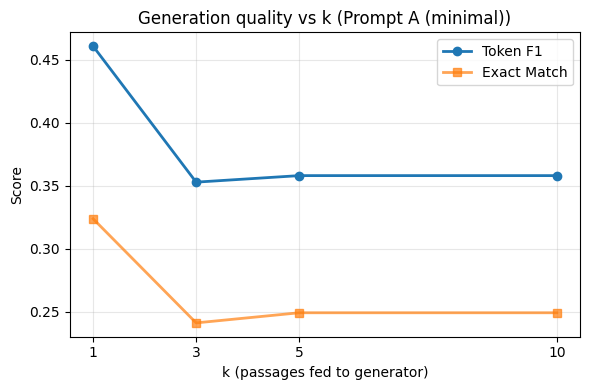

Plot saved to rag_k_sweep.png


In [37]:
# Plot how generation quality changes as k increases.
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    k_sweep_table.index,
    k_sweep_table["TokenF1"],
    marker="o",
    linewidth=2,
    label="Token F1"
)

ax.plot(
    k_sweep_table.index,
    k_sweep_table["ExactMatch"],
    marker="s",
    linewidth=2,
    label="Exact Match",
    alpha=0.7
)

ax.set_xlabel("k (passages fed to generator)")
ax.set_ylabel("Score")
ax.set_title(f"Generation quality vs k ({best_prompt_label})")
ax.set_xticks(k_sweep_table.index)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("rag_k_sweep.png", dpi=120)
plt.show()

print("Plot saved to rag_k_sweep.png")


## 6. Q5 — Error Analysis and Final Evaluation

In this section, I review the final system and analyse where it still makes mistakes. I first identify the best end-to-end setup from the earlier experiments, then inspect a sample of failed cases to understand the main error patterns.

I also use the provided similarity heatmap function to look at cases where passages are semantically close to each other, as this can explain why the retriever sometimes confuses similar but incorrect passages. Finally, I reflect on the system’s strengths, weaknesses, and what I would improve with more data or compute.

The held-out test set is evaluated separately after submission, so this section focuses on validation-set behaviour and error analysis.

### 6.1 Identify the best end-to-end system

Here, I identify the final system that will be carried forward. Since the final task is answer generation, I choose the setting with the highest validation Token F1 from the RAG experiments.

This locks in the retrieval setup, prompt design, and best value of `k` before I run the error analysis and test-set submission.

In [38]:
# Select the best k value using Token F1 from the RAG k-sweep.
best_k = int(k_sweep_table["TokenF1"].idxmax())
best_em = k_sweep_table.loc[best_k, "ExactMatch"]
best_f1 = k_sweep_table.loc[best_k, "TokenF1"]

print("=" * 75)
print("FINAL BEST SYSTEM CONFIGURATION")
print("=" * 75)

print("  Retrieval pipeline:")
print("    1. MiniLM dense vectors (Q2)")
print("    2. FAISS IndexFlatIP vector DB")
print(f"    3. Hybrid fusion: {hybrid_label}")
print(f"    4. Cross-encoder rerank: top-{best_top_n} candidates")

print("  Generation:")
print(f"    5. Flan-T5-small with {best_prompt_label}")
print(f"    6. k = {best_k} passages")

print("  Dev-set performance:")
print(f"    ExactMatch = {best_em:.4f}")
print(f"    TokenF1    = {best_f1:.4f}")

print("=" * 75)

# Generate the final predictions used for the error analysis.
preds_best = run_rag(
    final_results,
    qids,
    queries,
    val_corpus,
    best_prompt_template,
    k=best_k
)


FINAL BEST SYSTEM CONFIGURATION
  Retrieval pipeline:
    1. MiniLM dense vectors (Q2)
    2. FAISS IndexFlatIP vector DB
    3. Hybrid fusion: Hybrid-Weighted (alpha=0.9)
    4. Cross-encoder rerank: top-10 candidates
  Generation:
    5. Flan-T5-small with Prompt A (minimal)
    6. k = 1 passages
  Dev-set performance:
    ExactMatch = 0.3238
    TokenF1    = 0.4608


### 6.2 Structured error analysis

In this section, I inspect a sample of failed validation examples from the final RAG system. I focus on Exact Match failures, because these show cases where the generated answer did not fully match the gold answer.

I group the errors into categories such as retrieval misses, answer span mismatches, hallucinations, and cases where the correct passage was retrieved but not passed to the generator. The code first helps identify likely categories, and then I inspect 10 representative cases manually so the analysis is not based only on automatic labels.

In [39]:
# ============================================================
# 6.2 Structured Error Analysis
# ============================================================

import re
from collections import Counter
import pandas as pd

# Pattern for answers where the model refuses to answer.
idk_pattern = re.compile(
    r"\b(i do not know|i don't know|unknown|not given|not provided)\b",
    re.I
)


def safe_snippet(text, max_chars=300):
    """Shorten long passages for easier inspection."""
    text = str(text).replace("\n", " ").strip()
    return text[:max_chars] + ("..." if len(text) > max_chars else "")


def classify_failure_case(question, gold_answer, predicted_answer,
                          gold_idx, ranked_indices, corpus, k_used):
    """Classify one failed prediction using retrieval and generation evidence."""

    categories = []

    ranked_indices = list(ranked_indices)
    top20 = ranked_indices[:20]
    topk = ranked_indices[:k_used]

    em = exact_match_score(predicted_answer, gold_answer)
    f1 = token_f1_score(predicted_answer, gold_answer)

    gold_in_top20 = gold_idx in top20
    gold_in_topk = gold_idx in topk

    # Join only the passages given to the generator.
    generated_context = " ".join(corpus[i] for i in topk if i < len(corpus))
    generated_context_norm = normalize_text(generated_context)

    gold_answer_norm = normalize_text(gold_answer)
    pred_norm = normalize_text(predicted_answer)

    prediction_is_idk = bool(idk_pattern.search(str(predicted_answer)))

    if em == 1:
        return None

    if not gold_in_top20:
        categories.append("Retrieval miss")

    if gold_in_top20 and not gold_in_topk:
        categories.append("Gold retrieved but not passed to generator")

    if gold_in_topk and not prediction_is_idk:
        if gold_answer_norm in generated_context_norm and f1 < 0.8:
            categories.append("Answer span mismatch")

    if gold_in_topk and prediction_is_idk:
        categories.append("IDK despite relevant context")

    # Check whether the prediction appears unsupported by the given context.
    if not prediction_is_idk and pred_norm:
        pred_tokens = set(pred_norm.split())
        context_tokens = set(generated_context_norm.split())
        supported_overlap = len(pred_tokens & context_tokens)

        if f1 < 0.2 and supported_overlap == 0:
            categories.append("Hallucination")

    if f1 >= 0.2 and f1 < 1.0 and "Answer span mismatch" not in categories:
        categories.append("Other / partial match")

    if not categories:
        categories.append("Other / unclear")

    return {
        "question": question,
        "gold_answer": gold_answer,
        "predicted_answer": predicted_answer,
        "exact_match": em,
        "token_f1": f1,
        "gold_in_top20": gold_in_top20,
        "gold_in_topk": gold_in_topk,
        "gold_rank": (top20.index(gold_idx) + 1) if gold_in_top20 else None,
        "categories": categories,
        "top_retrieved_snippet": safe_snippet(corpus[ranked_indices[0]]) if ranked_indices else "",
        "gold_passage_snippet": safe_snippet(corpus[gold_idx]) if gold_idx < len(corpus) else "",
        "manual_note": ""
    }


# Build failure records for the final validation system.
failure_records = []

for ex in eval_examples:
    qid = ex["id"]
    question = ex["question"]
    gold_answer = ex["answer"]
    gold_idx = val_qrels[qid]

    predicted_answer = preds_best.get(qid, "")
    ranked_indices = final_results.get(qid, [])

    failure = classify_failure_case(
        question=question,
        gold_answer=gold_answer,
        predicted_answer=predicted_answer,
        gold_idx=gold_idx,
        ranked_indices=ranked_indices,
        corpus=val_corpus,
        k_used=best_k
    )

    if failure is not None:
        failure["qid"] = qid
        failure_records.append(failure)


# Count the failure categories.
category_counter = Counter()

for record in failure_records:
    for category in record["categories"]:
        category_counter[category] += 1

print("=" * 80)
print("STRUCTURED ERROR ANALYSIS")
print("=" * 80)
print(f"Total validation examples: {len(eval_examples)}")
print(f"Total Exact Match failures: {len(failure_records)}")
print(f"Exact Match successes: {len(eval_examples) - len(failure_records)}")
print()

print("Failure category distribution:")
for category, count in category_counter.most_common():
    percentage = count / len(failure_records) * 100 if failure_records else 0
    print(f"  {category:<45} {count:>4} cases ({percentage:>5.1f}%)")


# Select a balanced set of 10 cases for manual inspection.
selected_cases = []
seen_qids = set()

preferred_categories = [
    "Retrieval miss",
    "Gold retrieved but not passed to generator",
    "Answer span mismatch",
    "Hallucination",
    "IDK despite relevant context",
    "Other / partial match",
    "Other / unclear"
]

for category in preferred_categories:
    category_examples = [
        record for record in failure_records
        if category in record["categories"] and record["qid"] not in seen_qids
    ]

    for record in category_examples[:2]:
        selected_cases.append(record)
        seen_qids.add(record["qid"])

    if len(selected_cases) >= 10:
        break

# Fill any remaining slots with other failures.
for record in failure_records:
    if len(selected_cases) >= 10:
        break

    if record["qid"] not in seen_qids:
        selected_cases.append(record)
        seen_qids.add(record["qid"])


error_analysis_df = pd.DataFrame(selected_cases)

display_columns = [
    "qid",
    "question",
    "gold_answer",
    "predicted_answer",
    "token_f1",
    "gold_in_top20",
    "gold_in_topk",
    "gold_rank",
    "categories",
    "manual_note"
]

print()
print("=" * 80)
print(f"Selected {len(error_analysis_df)} representative failure cases for manual inspection")
print("=" * 80)

# Display the table in notebooks, or print it as text otherwise.
try:
    from IPython.display import display
    display(error_analysis_df[display_columns])
except ImportError:
    print(error_analysis_df[display_columns].to_string())


# Print each selected case in a readable format.
for i, record in enumerate(selected_cases, start=1):
    print("\n" + "=" * 100)
    print(f"CASE {i}: {record['qid']}")
    print("=" * 100)
    print(f"Question: {record['question']}")
    print(f"Gold answer: {record['gold_answer']}")
    print(f"Predicted answer: {record['predicted_answer']}")
    print(f"Token F1: {record['token_f1']:.3f}")
    print(f"Gold in top-20: {record['gold_in_top20']}")
    print(f"Gold passed to generator top-{best_k}: {record['gold_in_topk']}")
    print(f"Gold rank in top-20: {record['gold_rank']}")
    print(f"Categories: {', '.join(record['categories'])}")
    print()
    print("Top retrieved passage snippet:")
    print(record["top_retrieved_snippet"])
    print()
    print("Gold passage snippet:")
    print(record["gold_passage_snippet"])


# Save the selected cases for the report.
error_analysis_df.to_csv("q5_error_analysis_selected_cases.csv", index=False)
print("\nSaved selected error cases to q5_error_analysis_selected_cases.csv")

STRUCTURED ERROR ANALYSIS
Total validation examples: 871
Total Exact Match failures: 589
Exact Match successes: 282

Failure category distribution:
  Answer span mismatch                           504 cases ( 85.6%)
  Gold retrieved but not passed to generator      45 cases (  7.6%)
  Other / partial match                           40 cases (  6.8%)
  Hallucination                                   29 cases (  4.9%)
  Retrieval miss                                   2 cases (  0.3%)

Selected 10 representative failure cases for manual inspection


,qid,question,gold_answer,predicted_answer,token_f1,gold_in_top20,gold_in_topk,gold_rank,categories,manual_note
0,-1991117775599650072,who sang i'm giving up on you,A Great Big World and Christina Aguilera,Diana Ross,0.000000,False,False,NaN,[Retrieval miss],
1,-453840009279473504,where is cuba located on a world map,22 ° 00 ′ N 80 ° 00 ′ W,Near Santiago,0.000000,False,False,NaN,[Retrieval miss],
2,-4628267852301989966,when did michigan last win a national champion...,1989,2012,0.000000,True,False,4.0,[Gold retrieved but not passed to generator],
3,-5677793720723651646,this poster was created to increase support fo...,aiding the war effort,British public,0.000000,True,False,2.0,[Gold retrieved but not passed to generator],
4,9140154657058392803,who played taylor on the bold and beautiful,Hunter Tylo ( 1990 -- ) Sherilyn Wolter ( 1990 ),Hunter Tylo,0.500000,True,True,1.0,[Answer span mismatch],
5,7217548419303343001,when was the time the eagles won the superbowl,2017,2007,0.000000,True,True,1.0,"[Answer span mismatch, Hallucination]",
6,8239463385147663167,is jaffa cakes a biscuit or a cake,Cake,biscuit,0.000000,True,True,1.0,"[Answer span mismatch, Hallucination]",
7,-251770629620567718,how long was dark side of the moon number 1,42 : 49,3,0.000000,True,True,1.0,"[Answer span mismatch, Hallucination]",
8,-4733919216436438252,where can the mona lisa be found today,"Musée du Louvre , Paris",Musée du Louvre,0.857143,True,True,1.0,[Other / partial match],
9,-5332490337340067440,where did the california gold rush take place,Sierra Nevada and Northern California,Sierra Nevada and Northern California goldfields,0.909091,True,True,1.0,[Other / partial match],



CASE 1: -1991117775599650072
Question: who sang i'm giving up on you
Gold answer: A Great Big World and Christina Aguilera
Predicted answer: Diana Ross
Token F1: 0.000
Gold in top-20: False
Gold passed to generator top-1: False
Gold rank in top-20: None
Categories: Retrieval miss

Top retrieved passage snippet:
`` I 'm Coming Out '' One of the cover arts for German vinyl singles Single by Diana Ross from the album Diana B - side `` Give Up '' `` Friend to Friend '' `` Never Say I Do n't Love You '' `` My Old Piano '' Released August 22 , 1980 ( 1980 - 08 - 22 ) Format 7 `` , 12 '' Recorded December 1979 Ge...

Gold passage snippet:
`` Say Something '' Single by A Great Big World and Christina Aguilera from the album Is There Anybody Out There ? Released September 3 , 2013 ( 2013 - 09 - 03 ) Format CD digital download Recorded 2013 Genre Indie pop Length 3 : 49 Label Epic Songwriter ( s ) Ian Axel Chad King Mike Campbell Produc...

CASE 2: -453840009279473504
Question: where is cuba lo

**Notes for the report**

The table above gives 10 representative failure cases for manual inspection. I use these examples in the report to explain the main error patterns, such as retrieval misses, answer span mismatches, partial answers, hallucinations, and cases where the correct passage was retrieved but not passed to the generator.

The automatic labels are only a starting point. I still inspect the question, gold answer, predicted answer, top retrieved passage, and gold passage before deciding the final reason for each failure.

### 6.3 Similarity heatmap

In this section, I create a similarity heatmap for one representative failure case. I use the gold passage and the top retrieved passages, then compare their pairwise cosine similarities.

The aim is to see whether the system is confusing the gold passage with other passages that are topically similar. This helps explain cases where retrieval looks close but still does not select the exact correct evidence.

Heatmap built for query: who played taylor on the bold and beautiful
  Gold answer: Hunter Tylo ( 1990 -- ) Sherilyn Wolter ( 1990 )
  System prediction: Hunter Tylo



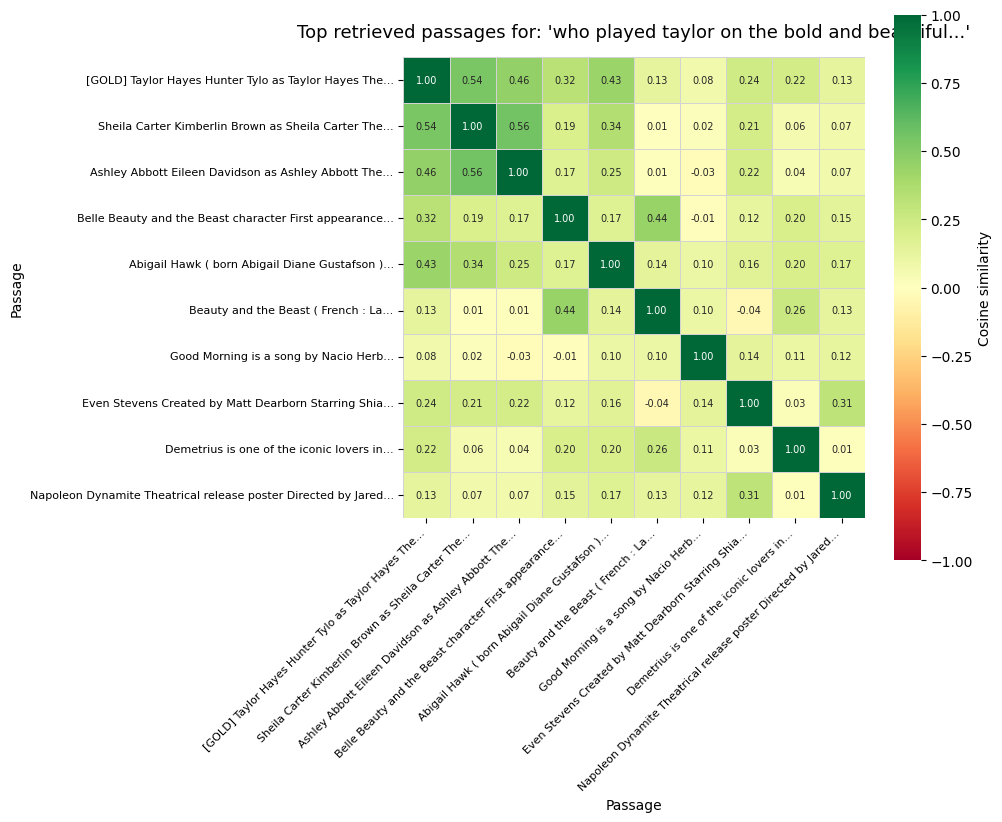

Heatmap saved to similarity_heatmap.png


In [40]:
# Choose a failure case where the gold passage is in the top-20 but not necessarily rank 1.
heatmap_candidates = [
    r for r in failure_records
    if r["gold_in_top20"] and "Retrieval miss" not in r["categories"]
]

if not heatmap_candidates:
    heatmap_candidates = failure_records[:1]

target = heatmap_candidates[0]
target_qid = target["qid"]
gold_idx = val_qrels[target_qid]
top10 = final_results[target_qid][:10]

# Use the gold passage plus the top retrieved passages.
passage_set = list(dict.fromkeys([gold_idx] + top10))[:10]

labels = []

for idx in passage_set:
    tag = "[GOLD] " if idx == gold_idx else ""
    labels.append(tag + make_short_label(val_corpus[idx], max_words=8))

selected_embeddings = passage_embeddings[passage_set]

print(f"Heatmap built for query: {target['question']}")
print(f"  Gold answer: {target['gold_answer']}")
print(f"  System prediction: {target['predicted_answer']}\n")

fig = plot_retrieval_similarity_heatmap(
    selected_embeddings,
    labels,
    title=f"Top retrieved passages for: '{target['question'][:60]}...'",
    annot_fontsize=7,
)

fig.savefig("similarity_heatmap.png", dpi=150, bbox_inches="tight")

print("Heatmap saved to similarity_heatmap.png")

**Notes for the report**

In the report, I use the heatmap to explain whether the system is confusing the gold passage with other semantically similar passages. High off-diagonal similarity values suggest that some retrieved passages are very close in meaning, even if they do not contain the exact answer.

This helps explain why some errors are not simple retrieval failures. In some cases, the system retrieves passages on the right topic, but a similar distractor passage is ranked above the gold passage or passed to the generator instead. This can lead to answer span mismatches or partially correct answers.

### 6.4 Reflection — strengths, weaknesses, and next steps

The final system has several strengths. The hybrid retrieval setup is more robust than using only TF-IDF or only dense retrieval, because it combines exact lexical matching with semantic matching. The cross-encoder re-ranker also improves the ordering of the top retrieved passages, which helps move the most relevant passages closer to rank 1. Using FAISS is also useful because the passage embeddings can be saved and reloaded without encoding the corpus again.

The main weakness is the generation stage. Flan-T5-small sometimes fails to extract the exact answer even when the correct passage is available, which leads to answer span mismatches or partially correct answers. The model also has a limited input length, so giving it too many passages can introduce noise or cause useful evidence to be cut off. Retrieval errors are also difficult to recover from, because if the correct passage is not retrieved, the generator cannot produce the right answer reliably.

With more compute or data, I would try a larger generation model such as Flan-T5-base, fine-tune the dense retriever on Natural Questions examples, and improve query expansion using better prompts or a stronger LLM. I would also investigate reader-aware re-ranking, where passages are ranked not only by topic similarity but also by whether they contain an extractable answer span.

## 7. Final summary table

This final table brings together the main results from the notebook. It shows how performance changes from the TF-IDF baseline, through dense and improved retrieval methods, and then to the full RAG system.

In [41]:
# Summarise the retrieval results from each stage.
retrieval_metrics = ["Recall@1", "Recall@5", "Recall@20", "Recall@100", "MRR"]

retrieval_summary = pd.DataFrame([
    {
        "Stage": "Q1 TF-IDF",
        **{m: tfidf_metrics[m] for m in retrieval_metrics}
    },
    {
        "Stage": "Q2 Dense (MiniLM)",
        **{m: dense_metrics[m] for m in retrieval_metrics}
    },
    {
        "Stage": f"Q3 Hybrid ({hybrid_label})",
        **{m: hybrid_metrics[m] for m in retrieval_metrics}
    },
    {
        "Stage": f"Q3 LLM Query Expansion (beta={best_beta})",
        **{m: qe_metrics[m] for m in retrieval_metrics}
    },
    {
        "Stage": f"Q3 + Cross-encoder rerank (N={best_top_n})",
        **{m: reranked_metrics[m] for m in retrieval_metrics}
    },
    {
        "Stage": "Q4 Final retrieval (FAISS + hybrid + rerank)",
        **{m: final_retr_metrics[m] for m in retrieval_metrics}
    },
]).set_index("Stage")

print("Retrieval performance across the pipeline")
print("=" * 100)
print(retrieval_summary.round(4).to_string())

Retrieval performance across the pipeline
                                              Recall@1  Recall@5  Recall@20  Recall@100     MRR
Stage                                                                                          
Q1 TF-IDF                                       0.5476    0.7842     0.8794      0.9173  0.6546
Q2 Dense (MiniLM)                               0.9208    0.9943     0.9977      1.0000  0.9537
Q3 Hybrid (Hybrid-Weighted (alpha=0.9))         0.9196    0.9954     0.9977      1.0000  0.9545
Q3 LLM Query Expansion (beta=1.0)               0.9208    0.9943     0.9977      1.0000  0.9537
Q3 + Cross-encoder rerank (N=10)                0.9380    0.9954     0.9977      1.0000  0.9630
Q4 Final retrieval (FAISS + hybrid + rerank)    0.9380    0.9954     0.9977      1.0000  0.9630


In [42]:
# Summarise the generation results from the RAG experiments.
generation_summary = pd.DataFrame([
    {
        "Stage": "Retrieval-only (top-1 passage as answer)",
        "ExactMatch": metrics_retr_only["ExactMatch"],
        "TokenF1":    metrics_retr_only["TokenF1"]
    },
    {
        "Stage": f"Full RAG, Prompt A, k={K_DEFAULT}",
        "ExactMatch": metrics_A["ExactMatch"],
        "TokenF1":    metrics_A["TokenF1"]
    },
    {
        "Stage": f"Full RAG, Prompt B, k={K_DEFAULT}",
        "ExactMatch": metrics_B["ExactMatch"],
        "TokenF1":    metrics_B["TokenF1"]
    },
    {
        "Stage": f"Full RAG, {best_prompt_label}, k={best_k} (FINAL)",
        "ExactMatch": best_em,
        "TokenF1":    best_f1
    },
]).set_index("Stage")

print("Generation performance")
print("=" * 80)
print(generation_summary.round(4).to_string())

Generation performance
                                           ExactMatch  TokenF1
Stage                                                         
Retrieval-only (top-1 passage as answer)       0.0000   0.1289
Full RAG, Prompt A, k=5                        0.2491   0.3580
Full RAG, Prompt B, k=5                        0.2239   0.3126
Full RAG, Prompt A (minimal), k=1 (FINAL)      0.3238   0.4608


In [43]:
# Check that the key final-system variables exist before running Section 8.
print("best_k exists:", "best_k" in globals())
print("best_top_n exists:", "best_top_n" in globals())
print("best_prompt_template exists:", "best_prompt_template" in globals())
print("hybrid_label exists:", "hybrid_label" in globals())
print("cross_encoder exists:", "cross_encoder" in globals())

best_k exists: True
best_top_n exists: True
best_prompt_template exists: True
hybrid_label exists: True
cross_encoder exists: True


### 8.1 Load the test set

In this section, I load the held-out test corpus and test questions. The code assumes that `test_corpus.json` and `test_questions.json` are in the current working directory. In Colab, these files need to be uploaded before running this section.

In [44]:
import json
import os

# Set the test file paths.
TEST_CORPUS_PATH = "test_corpus.json"
TEST_QUESTIONS_PATH = "test_questions.json"

assert os.path.exists(TEST_CORPUS_PATH), f"Missing {TEST_CORPUS_PATH} — upload to working dir."
assert os.path.exists(TEST_QUESTIONS_PATH), f"Missing {TEST_QUESTIONS_PATH} — upload to working dir."

# Load the test corpus and questions.
with open(TEST_CORPUS_PATH) as f:
    test_corpus_data = json.load(f)

with open(TEST_QUESTIONS_PATH) as f:
    test_questions_data = json.load(f)

# Store passage text and corpus IDs in the same order.
test_corpus = [row["context"] for row in test_corpus_data]
test_corpus_id = [row["corpus_id"] for row in test_corpus_data]

# Store test question IDs and question text.
test_qids = [row["question_id"] for row in test_questions_data]
test_queries = [row["question"] for row in test_questions_data]

print(f"Test corpus:    {len(test_corpus):,} passages")
print(f"Test questions: {len(test_queries):,}")
print(f"Sample corpus id: {test_corpus_id[0]}")
print(f"Sample question:  [{test_qids[0]}] {test_queries[0]}")

Test corpus:    1,989 passages
Test questions: 1,000
Sample corpus id: C0092
Sample question:  [Q0001] when is the next deadpool movie being released


### 8.2 Encode the test corpus

Here, I encode the test passages using the same MiniLM model used earlier. I cache the embeddings so that the test corpus does not need to be encoded again if the notebook is re-run.

In [45]:
test_passage_cache = model_cache_path(PRIMARY_MODEL_NAME, tag="test")
print("Encoding test corpus with the same MiniLM bi-encoder as Q2...")
t0 = time.time()
test_passage_embeddings = encode_corpus(encoder, test_corpus, test_passage_cache, batch_size=16)
print(f"  Total time: {time.time()-t0:.1f}s")
print(f"  Shape: {test_passage_embeddings.shape}")


Encoding test corpus with the same MiniLM bi-encoder as Q2...
  Encoding 1,989 passages (batch_size=16) ...


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

  Encoded in 4.9s (402 passages/sec)
  Total time: 5.0s
  Shape: (1989, 384)


### 8.3 Build the FAISS index for the test corpus

In this section, I build a FAISS `IndexFlatIP` index for the test passage embeddings. This uses the same indexing method as the validation pipeline, and I save the index so it can be reloaded without rebuilding it.

In [46]:
import faiss

print(f"Building FAISS test index over {len(test_passage_embeddings):,} passages...")
t0 = time.time()
test_faiss_index = faiss.IndexFlatIP(test_passage_embeddings.shape[1])
test_faiss_index.add(test_passage_embeddings.astype(np.float32))
print(f"  Built in {time.time()-t0:.2f}s | ntotal={test_faiss_index.ntotal}")

TEST_INDEX_PATH = "faiss_minilm_test.index"
faiss.write_index(test_faiss_index, TEST_INDEX_PATH)
print(f"  Saved to {TEST_INDEX_PATH}")

Building FAISS test index over 1,989 passages...
  Built in 0.00s | ntotal=1989
  Saved to faiss_minilm_test.index


### 8.4 Build the TF-IDF index for the test corpus

The hybrid retrieval step also needs TF-IDF scores, so I build a new TF-IDF index for the test corpus using the same settings as Q1. I fit it on the test passages so that the vocabulary matches the test corpus rather than the validation corpus.

In [47]:
test_vectorizer = TfidfVectorizer(
    lowercase=True, stop_words="english", ngram_range=(1, 2),
    min_df=2, max_df=0.95, sublinear_tf=True, norm="l2",
)
t0 = time.time()
test_doc_matrix = test_vectorizer.fit_transform(test_corpus)
print(f"Test TF-IDF index built in {time.time()-t0:.2f}s, shape={test_doc_matrix.shape}")

Test TF-IDF index built in 0.72s, shape=(1989, 39684)


### 8.5 Broad retrieval on test queries

Here, I run both retrieval methods on the test questions. I use FAISS for dense retrieval and TF-IDF for sparse retrieval, producing top-100 rankings from each method. These rankings are then used for the hybrid fusion step.

In [48]:
# Run dense retrieval with the FAISS test index.
print(f"Dense retrieval (FAISS) for {len(test_queries)} test queries...")
t0 = time.time()

test_q_emb = encoder.encode(
    test_queries,
    batch_size=64,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=False
).astype(np.float32)

D_test, I_test = test_faiss_index.search(test_q_emb, 100)

test_vdb_results = {
    test_qids[i]: I_test[i].tolist()
    for i in range(len(test_qids))
}

print(f"  Done in {time.time() - t0:.2f}s")


# Run TF-IDF retrieval for the test queries.
print(f"\nTF-IDF retrieval for {len(test_queries)} test queries...")
t0 = time.time()

test_q_tfidf = test_vectorizer.transform(test_queries)
test_sims_tfidf = linear_kernel(test_q_tfidf, test_doc_matrix)

test_tfidf_results = {}

for row_i, qid in enumerate(test_qids):
    s = test_sims_tfidf[row_i]

    if hasattr(s, "toarray"):
        s = s.toarray().ravel()
    else:
        s = np.asarray(s).ravel()

    K_eff = min(100, len(s))

    if K_eff >= len(s):
        top_idx = np.argsort(-s)
    else:
        part = np.argpartition(-s, K_eff)[:K_eff]
        top_idx = part[np.argsort(-s[part])]

    test_tfidf_results[qid] = top_idx.tolist()

print(f"  Done in {time.time() - t0:.2f}s")

Dense retrieval (FAISS) for 1000 test queries...
  Done in 0.25s

TF-IDF retrieval for 1000 test queries...
  Done in 0.05s


### 8.6 Apply hybrid fusion and cross-encoder re-ranking

In this step, I apply the best retrieval settings found on the validation set to the test queries. This means using the selected hybrid fusion method and then re-ranking the top candidates with the cross-encoder using the best `top_N` value from Q3.

In [49]:
# Apply the best hybrid method from Q3.
if "RRF" in hybrid_label:
    print(f"Hybrid fusion: RRF (k_rrf={best_k_rrf})")

    test_hybrid = rrf_fuse(
        [test_tfidf_results, test_vdb_results],
        k_rrf=best_k_rrf,
        top_k=100
    )

else:
    print(f"Hybrid fusion: weighted (alpha={best_alpha})")

    # Recreate the weighted score fusion for the test set.
    dense_scores = test_q_emb @ test_passage_embeddings.T

    tfidf_scores = (
        test_sims_tfidf.toarray()
        if hasattr(test_sims_tfidf, "toarray")
        else np.asarray(test_sims_tfidf)
    )

    tfidf_n = minmax_normalise(tfidf_scores)
    dense_n = minmax_normalise(dense_scores)

    fused_scores = best_alpha * dense_n + (1 - best_alpha) * tfidf_n

    test_hybrid = {}

    for row_i, qid in enumerate(test_qids):
        s = fused_scores[row_i]
        K_eff = min(100, len(s))

        if K_eff >= len(s):
            top_idx = np.argsort(-s)
        else:
            part = np.argpartition(-s, K_eff)[:K_eff]
            top_idx = part[np.argsort(-s[part])]

        test_hybrid[qid] = top_idx.tolist()


# Re-rank the hybrid results with the cross-encoder.
print(f"\nCross-encoder reranking top-{best_top_n} of each test query...")
t0 = time.time()

test_final_results = cross_encoder_rerank(
    test_hybrid,
    test_queries,
    test_qids,
    test_corpus,
    cross_encoder,
    top_n=best_top_n,
    batch_size=64
)

print(f"  Done in {time.time() - t0:.1f}s")

print(
    f"\nTest retrieval pipeline complete. "
    f"Got top-100 rankings for {len(test_final_results)} queries."
)

Hybrid fusion: weighted (alpha=0.9)

Cross-encoder reranking top-10 of each test query...
  Done in 23.0s

Test retrieval pipeline complete. Got top-100 rankings for 1000 queries.


### 8.7 Generate answers with the final RAG setup

Here, I use the final RAG configuration selected from the validation experiments. This uses the same prompt template, the same best value of `k`, and the same Flan-T5-small model to generate answers for the held-out test questions.

In [50]:
# Use the final prompt label, with a fallback if the label is missing.
prompt_label_for_test = globals().get("best_prompt_label", "Best validation prompt")

print(f"Generating answers for {len(test_qids)} test questions ...")
print(f"  Prompt:  {prompt_label_for_test}")
print(f"  k:       {best_k}")
print(f"  Model:   {GEN_MODEL_NAME}")
print()

t0 = time.time()
test_answers = {}

for qi, qid in enumerate(test_qids):
    # Get the final top-k passages for this test question.
    top_k_idx = test_final_results.get(qid, [])[:best_k]
    passages = [test_corpus[i] for i in top_k_idx]

    # Generate the final answer.
    test_answers[qid] = generate_answer(
        test_queries[qi],
        passages,
        prompt_template=best_prompt_template
    )

    if (qi + 1) % 100 == 0:
        print(
            f"  Generated {qi + 1}/{len(test_qids)} answers... "
            f"({time.time() - t0:.1f}s elapsed)"
        )

elapsed = time.time() - t0

print(
    f"\nGeneration done in {elapsed:.1f}s "
    f"({len(test_qids) / elapsed:.1f} q/s)"
)

print("\nSample answers:")

for i, qid in enumerate(test_qids[:5]):
    print(f"  [{qid}] {test_queries[i]}")
    print(f"        → {test_answers[qid]}\n")

Generating answers for 1000 test questions ...
  Prompt:  Prompt A (minimal)
  k:       1
  Model:   google/flan-t5-small

  Generated 100/1000 answers... (9.6s elapsed)
  Generated 200/1000 answers... (17.8s elapsed)
  Generated 300/1000 answers... (26.5s elapsed)
  Generated 400/1000 answers... (34.5s elapsed)
  Generated 500/1000 answers... (45.3s elapsed)
  Generated 600/1000 answers... (54.4s elapsed)
  Generated 700/1000 answers... (63.7s elapsed)
  Generated 800/1000 answers... (72.1s elapsed)
  Generated 900/1000 answers... (80.3s elapsed)
  Generated 1000/1000 answers... (89.1s elapsed)

Generation done in 89.1s (11.2 q/s)

Sample answers:
  [Q0001] when is the next deadpool movie being released
        → May 18 , 2018

  [Q0002] the south west wind blows across nigeria between
        → Central and Central

  [Q0003] who wrote the first declaration of human rights
        → Eleanor Roosevelt

  [Q0004] where did the first african american air force unit train
        → Tuskeg

### 8.8 Write the submission CSV

In this section, I write the final test predictions to `submission.csv` in the required format. Each row contains the test `question_id`, the retrieved passage IDs, and the generated answer.

The retrieved passages are saved as semicolon-separated `corpus_id` values, not numeric index positions. I include the top 100 retrieved IDs for each question so the submitted ranking contains a full retrieval list.

In [51]:
import csv


N_RETRIEVED_TO_SUBMIT = 100
SUBMISSION_PATH = "submission.csv"

print(f"Writing submission to {SUBMISSION_PATH} ...")

with open(SUBMISSION_PATH, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["question_id", "retrieved_context_ids", "answer"])

    for qid in test_qids:
        top_idx = test_final_results.get(qid, [])[:N_RETRIEVED_TO_SUBMIT]

        # Convert numeric passage positions back to corpus_id values.
        retrieved_ids = ";".join(test_corpus_id[i] for i in top_idx)

        # Clean the generated answer before writing it.
        answer = test_answers.get(qid, "")
        answer = " ".join(answer.split())

        writer.writerow([qid, retrieved_ids, answer])


# Check the saved file has the expected number of rows.
n_rows = sum(1 for _ in open(SUBMISSION_PATH)) - 1
size = os.path.getsize(SUBMISSION_PATH)

print(f"  Wrote {n_rows} rows ({size / 1024:.1f} KB)")
print(f"  Expected: {len(test_qids)} rows  → {'OK' if n_rows == len(test_qids) else 'MISMATCH'}")

print(f"\nFirst 3 rows of {SUBMISSION_PATH}:")

with open(SUBMISSION_PATH) as f:
    for i, line in enumerate(f):
        if i > 3:
            break

        # Shorten the retrieved IDs only for display.
        if i > 0:
            parts = line.rstrip().split(",", 2)

            if len(parts) >= 2 and len(parts[1]) > 60:
                parts[1] = parts[1][:60] + "..."

            line = ",".join(parts) + "\n"

        print(f"  {line.rstrip()}")

Writing submission to submission.csv ...
  Wrote 1000 rows (609.3 KB)
  Expected: 1000 rows  → OK

First 3 rows of submission.csv:
  question_id,retrieved_context_ids,answer
  Q0001,C0001;C0088;C1385;C1403;C1091;C1364;C0002;C0796;C1145;C0327;...,"May 18 , 2018"
  Q0002,C0003;C1249;C0004;C0175;C1119;C1182;C0259;C0890;C1936;C1926;...,Central and Central
  Q0003,C0006;C0630;C1290;C0971;C1840;C1147;C1770;C1004;C0977;C0794;...,Eleanor Roosevelt


### 8.9 Submission sanity checks

Before submitting, I run a few final checks on `submission.csv`. These checks make sure the file has the right number of rows, contains every test question exactly once, uses valid corpus IDs, and does not contain blank answers.

In [52]:
from collections import Counter

# Reload the saved submission file.
with open(SUBMISSION_PATH, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)

# Check the row count.
assert len(rows) == len(test_qids), \
    f"Row count {len(rows)} != question count {len(test_qids)}"

print(f"✓ Row count correct: {len(rows)} rows")

# Check every test question appears once.
all_row_qids = [r["question_id"] for r in rows]
row_qids = set(all_row_qids)
input_qids = set(test_qids)

missing = input_qids - row_qids
extra = row_qids - input_qids

duplicate_qids = [
    qid for qid, count in Counter(all_row_qids).items()
    if count > 1
]

assert not missing, f"Missing question IDs in submission: {list(missing)[:5]}"
assert not extra, f"Extra unknown IDs in submission: {list(extra)[:5]}"
assert not duplicate_qids, f"Duplicate question IDs in submission: {duplicate_qids[:5]}"

print(f"✓ All {len(input_qids)} question IDs present, no extras, no duplicates")

# Check all retrieved passage IDs are valid corpus IDs.
valid_corpus_ids = set(test_corpus_id)
bad_ids = []

for r in rows:
    retrieved_ids = [
        cid for cid in r["retrieved_context_ids"].split(";")
        if cid.strip()
    ]

    for cid in retrieved_ids:
        if cid not in valid_corpus_ids:
            bad_ids.append((r["question_id"], cid))

            if len(bad_ids) >= 5:
                break

    if len(bad_ids) >= 5:
        break

assert not bad_ids, f"Invalid corpus IDs found: {bad_ids}"
print("✓ All retrieved_context_ids are valid corpus IDs")

# Check for blank answers.
blank_answers = sum(1 for r in rows if not str(r["answer"]).strip())

print(f"✓ Answers: {len(rows) - blank_answers} non-blank, {blank_answers} blank")

if blank_answers > 0:
    print(f"  ⚠ {blank_answers} blank answers — check whether these came from generation failures.")

# Count answers where the model says it does not know.
idk_check_pattern = globals().get(
    "idk_pat",
    re.compile(r"\b(i do not know|i don't know|unknown|not given|not provided)\b", re.I)
)

idk_count = sum(
    1 for r in rows
    if idk_check_pattern.search(str(r["answer"]))
)

print(f"  'I don't know' rate on test: {idk_count}/{len(rows)} ({idk_count / len(rows):.1%})")

print(f"\n✓ {SUBMISSION_PATH} is ready to submit.")

✓ Row count correct: 1000 rows
✓ All 1000 question IDs present, no extras, no duplicates
✓ All retrieved_context_ids are valid corpus IDs
✓ Answers: 1000 non-blank, 0 blank
  'I don't know' rate on test: 0/1000 (0.0%)

✓ submission.csv is ready to submit.


### Final configuration carried forward to the held-out test set

The final system used for the held-out test set is the best validation setup selected earlier in the notebook.

**Retrieval pipeline**

- MiniLM dense embeddings with a FAISS `IndexFlatIP` vector index
- Hybrid fusion with TF-IDF using the selected validation setting
- Cross-encoder re-ranking using the selected validation `top_N` value

**Generation pipeline**

- Flan-T5-small
- Best prompt selected from the validation prompt comparison
- Best `k` value selected from the validation RAG k-sweep

This is the locked configuration used to generate `submission.csv`.